## *Pepper Prices Analysis*

---

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)
import math
import missingno as msno

---

## *Importing data :*

In [6]:
import os
%pwd
os.chdir("../")
%pwd

'c:\\Users\\Omar\\Desktop\\Omar_Files\\Python_Analysis\\Pepper_Prices_Analysis\\Pepper_Prices_Analysis'

In [7]:
df=pd.read_csv('Data_Sets/actual_data.csv')

---  
## *Data Over View :*

In [8]:
df.head()

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply
0,2015-08-17,2015-08-23,1,yellow,7.249725,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.025,0.5,0.5
1,2015-08-17,2015-08-23,1,red,7.600215,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5
2,2015-08-17,2015-08-23,1,green,7.074805,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.525,7.225,0.5,0.5
3,2015-08-24,2015-08-30,1,green,7.025085,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.225,0.5,0.5
4,2015-08-24,2015-08-30,1,red,7.722255,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5


In [9]:
df.shape

(1272, 19)

---
# *Data Cleaning :*

* *We will :*  
*1. Remove the rows with value -1*  
*2. Na Values check*  
*3. Fiiling Na vlaues using interplolate with linear moethod*  
*4. Convert week_start_dt & week_end_dt to datetime datatype*  
*5. Detect numerical_cols,categorical_cols,boolean_cols, and date_cols*

* *Removing the rows with value -1*

In [10]:
df=df[df["total_volume"]!=-1]
df.shape

(1215, 19)

* *Na Values :*

In [11]:
print(f"The number of Na values is : {df.isna().sum().sum()}")
print("The number of Na values per column -if exist- is :")
df.isna().sum()

The number of Na values is : 62
The number of Na values per column -if exist- is :


week_start_dt        0
week_end_dt          0
vietnam_season       0
p_color              0
price                0
total_volume         0
brazil               0
india                0
vietnam              0
indonesia            0
china                0
brazil_season        0
indonesia_season     0
india_season         0
china_season         0
jordan_max_price    31
jordan_min_price    31
demand               0
supply               0
dtype: int64

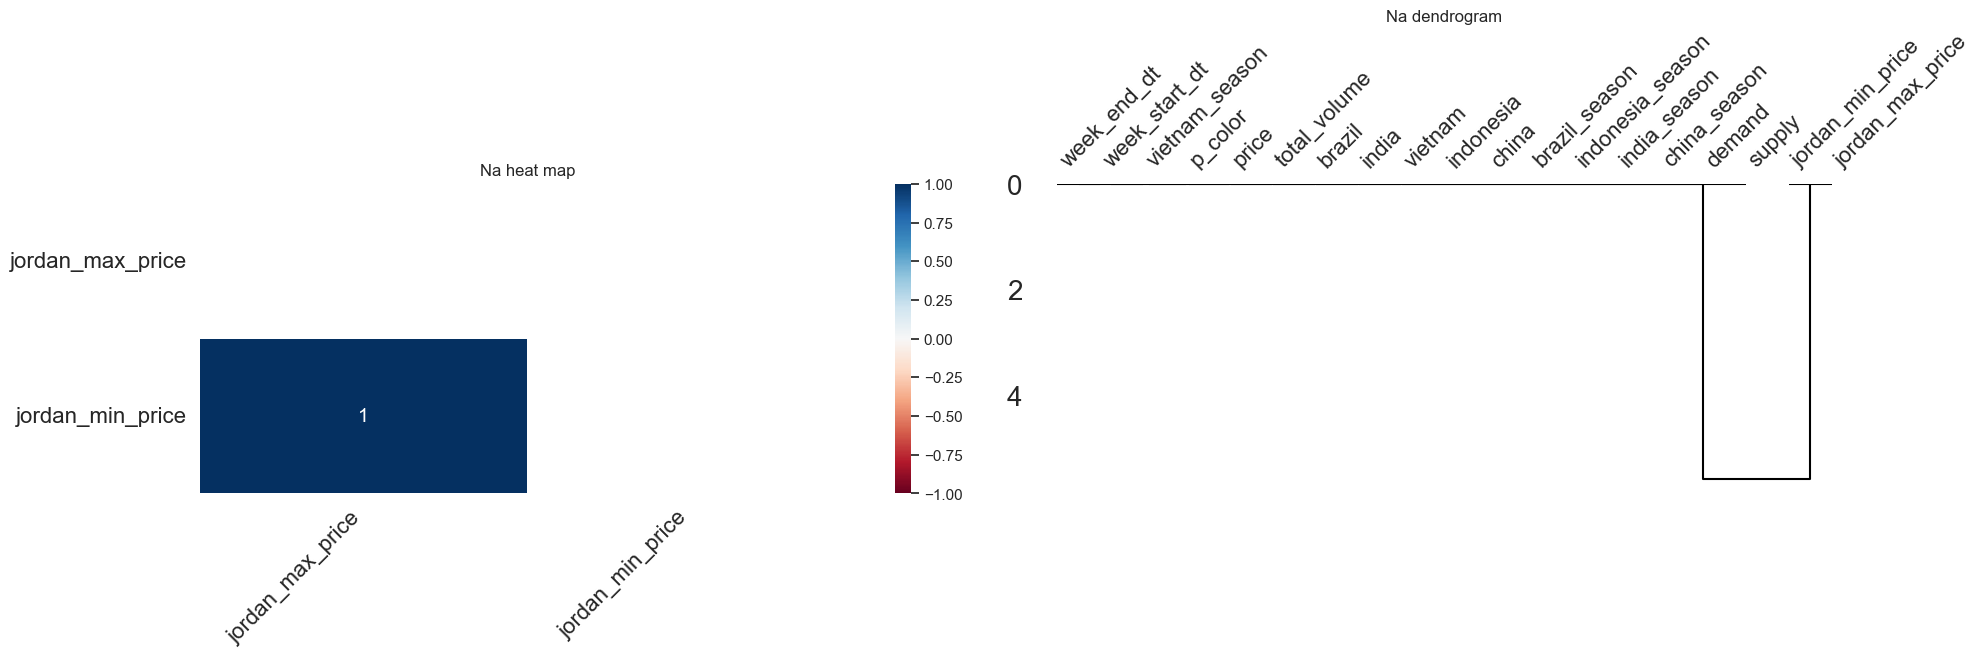

In [12]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
msno.heatmap(df,ax=ax1);
ax1.set_title("Na heat map")


ax2 = fig.add_subplot(gs[0, 1])
msno.dendrogram(df,ax=ax2);
ax2.set_title("Na dendrogram")

plt.tight_layout()
plt.show()

* *Fiiling Na vlaues using interplolate with linear moethod*

In [13]:
df.interpolate(method="linear",inplace=True,limit_direction="backward")

In [14]:
print(f"The number of Na values is : {df.isna().sum().sum()}")

The number of Na values is : 0


* *dataset info :*

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1215 entries, 57 to 1271
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week_start_dt     1215 non-null   object 
 1   week_end_dt       1215 non-null   object 
 2   vietnam_season    1215 non-null   int64  
 3   p_color           1215 non-null   object 
 4   price             1215 non-null   float64
 5   total_volume      1215 non-null   float64
 6   brazil            1215 non-null   float64
 7   india             1215 non-null   float64
 8   vietnam           1215 non-null   float64
 9   indonesia         1215 non-null   float64
 10  china             1215 non-null   float64
 11  brazil_season     1215 non-null   bool   
 12  indonesia_season  1215 non-null   bool   
 13  india_season      1215 non-null   bool   
 14  china_season      1215 non-null   bool   
 15  jordan_max_price  1215 non-null   float64
 16  jordan_min_price  1215 non-null   float64
 17 

* *Convert week_start_dt & week_end_dt to datetime datatype :*

In [16]:
df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

* *Detect numerical_cols,categorical_cols,boolean_cols, and date_cols :*

In [17]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

In [18]:
print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


---
## *Feature Engeneering :*

*Create new features from existing ones : year,month_name,month,year_int,day_name,Weekday_Number,and DayOfMonth*

In [19]:
df.to_csv("Data_Sets/data_set_for_stats.csv")
df_copy=df.copy()
df_copy["month"]=df_copy["week_start_dt"].dt.month
df_copy["year"]=df_copy["week_start_dt"].dt.year
df_copy["day_name"]=df_copy["week_start_dt"].dt.day_name()
df_copy['Weekday_Number'] = df_copy["week_start_dt"].dt.dayofweek
df_copy['DayOfMonth'] = df_copy['week_start_dt'].dt.day
df_copy.head(15)

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,...,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,day_name,Weekday_Number,DayOfMonth
57,2015-12-28,2016-01-03,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,6.625,6.325,0.50,0.5,12,2015,Monday,0,28
58,2015-12-28,2016-01-03,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.525,7.125,0.51,0.5,12,2015,Monday,0,28
59,2015-12-28,2016-01-03,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.425,7.025,16.55,0.5,12,2015,Monday,0,28
60,2016-01-04,2016-01-10,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.525,7.025,271.16,0.5,1,2016,Monday,0,4
61,2016-01-04,2016-01-10,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.625,7.125,42.33,0.5,1,2016,Monday,0,4
62,2016-01-04,2016-01-10,2,green,6.599075,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,6.625,6.325,0.58,0.5,1,2016,Monday,0,4
63,2016-01-11,2016-01-17,2,yellow,7.200005,2418196.7,26727.0,72230.2,2319239.4,0.0,...,False,7.525,7.125,712.22,0.5,1,2016,Monday,0,11
64,2016-01-11,2016-01-17,2,red,7.175335,2418196.7,26727.0,72230.2,2319239.4,0.0,...,False,7.625,7.325,28.52,0.5,1,2016,Monday,0,11
65,2016-01-11,2016-01-17,2,green,6.599075,2418196.7,26727.0,72230.2,2319239.4,0.0,...,False,6.725,6.325,0.63,0.5,1,2016,Monday,0,11
66,2016-01-18,2016-01-24,2,yellow,7.200005,2774383.5,85537.4,51157.6,2637688.5,0.0,...,False,7.525,7.250,701.26,0.5,1,2016,Monday,0,18


*will drop the day name as it has only one unique value for all*

In [20]:
df_copy=df_copy.drop(["day_name","Weekday_Number"],axis=1)

In [21]:
ordinal_cols=df_copy[["vietnam_season","year","month","DayOfMonth"]].columns.tolist()
ordinal_cols

['vietnam_season', 'year', 'month', 'DayOfMonth']

---  
## *Exploratory Data Analysis-EDA*

* *We will :*  
*1. have a quick look at the Number of unique values in each feature :*  
*2. numerical_cols EDA : distribution ,basic statistic summary,correlation and visualization*  
*3. categorical_cols EDA : distribution ,basic statistic summary and visualization*      
*4. boolean_cols EDA : distribution ,basic statistic summary and visualization*      
*5. Detect numerical_cols,categorical_cols,boolean_cols, and date_cols*

* *Number of unique values in each feature :*

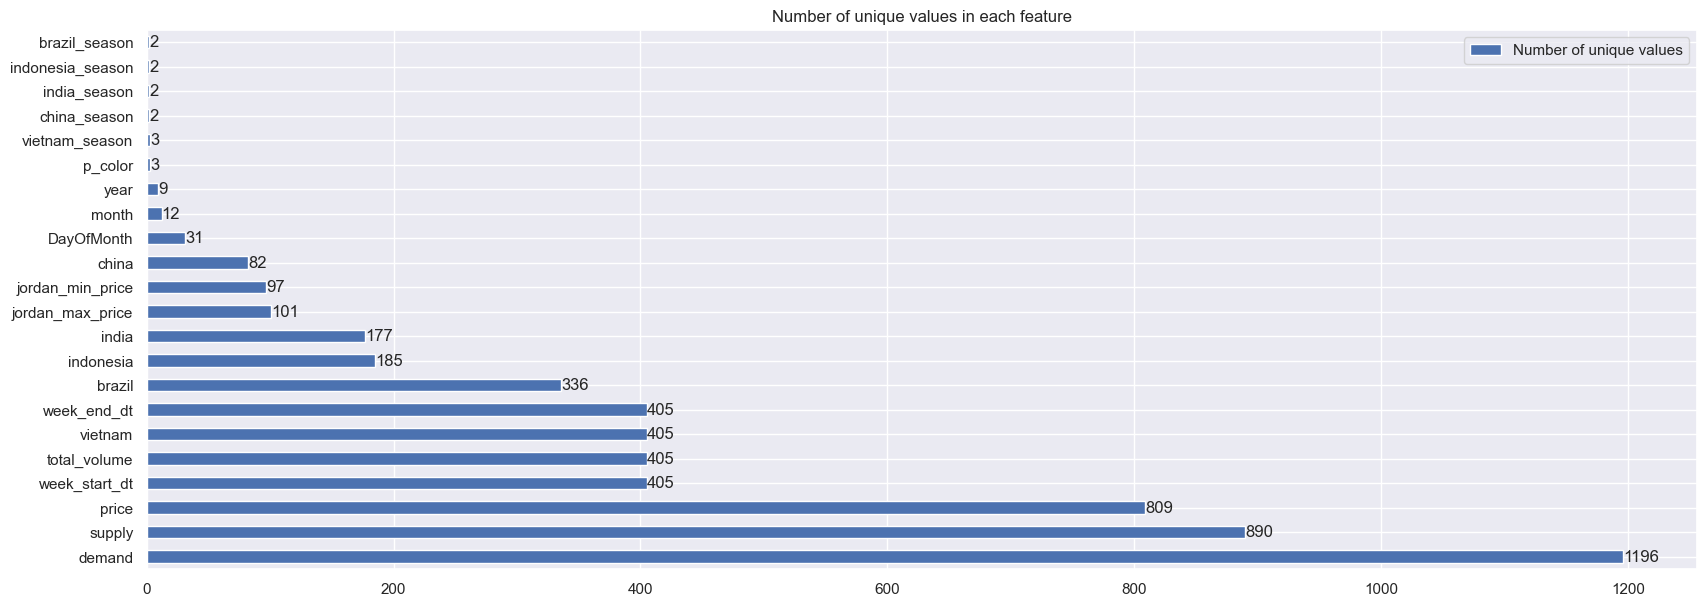

In [22]:
ax=df_copy.nunique().to_frame().rename(columns={0:"Number of unique values"}).sort_values(by="Number of unique values",
                                                                                  ascending=False).plot(kind="barh",figsize=(20,7),title="Number of unique values in each feature");

ax.bar_label(ax.containers[0]);

### *numerical_cols*

* *numerical_cols basic summary statistics :*

In [23]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vietnam_season,1215.0,1.918519e+00,0.770616,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00
price,1215.0,8.008801e+00,1.367471,6.299625,7.000047e+00,7.600120e+00,8.600505e+00,1.408459e+01
total_volume,1215.0,2.244701e+06,482013.003283,325471.000000,1.938246e+06,2.254902e+06,2.541123e+06,3.555979e+06
brazil,1215.0,2.453030e+05,238532.956065,0.000000,1.060860e+04,1.754931e+05,4.435506e+05,8.776478e+05
india,1215.0,2.874410e+04,55904.812350,0.000000,0.000000e+00,0.000000e+00,3.102260e+04,3.489974e+05
vietnam,1215.0,1.806530e+06,573830.707115,220121.500000,1.402234e+06,1.785219e+06,2.204095e+06,3.549175e+06
indonesia,1215.0,1.549481e+05,243242.278078,0.000000,0.000000e+00,2.150300e+03,2.784692e+05,1.061051e+06
china,1215.0,8.487645e+03,21366.041220,0.000000,0.000000e+00,0.000000e+00,7.257400e+03,2.109202e+05
jordan_max_price,1215.0,8.509403e+00,1.494271,6.225000,7.425000e+00,8.025000e+00,9.225000e+00,1.422500e+01
jordan_min_price,1215.0,7.926667e+00,1.367845,6.025000,6.925000e+00,7.525000e+00,8.525000e+00,1.372500e+01


* *Visalizing numerical_cols:*

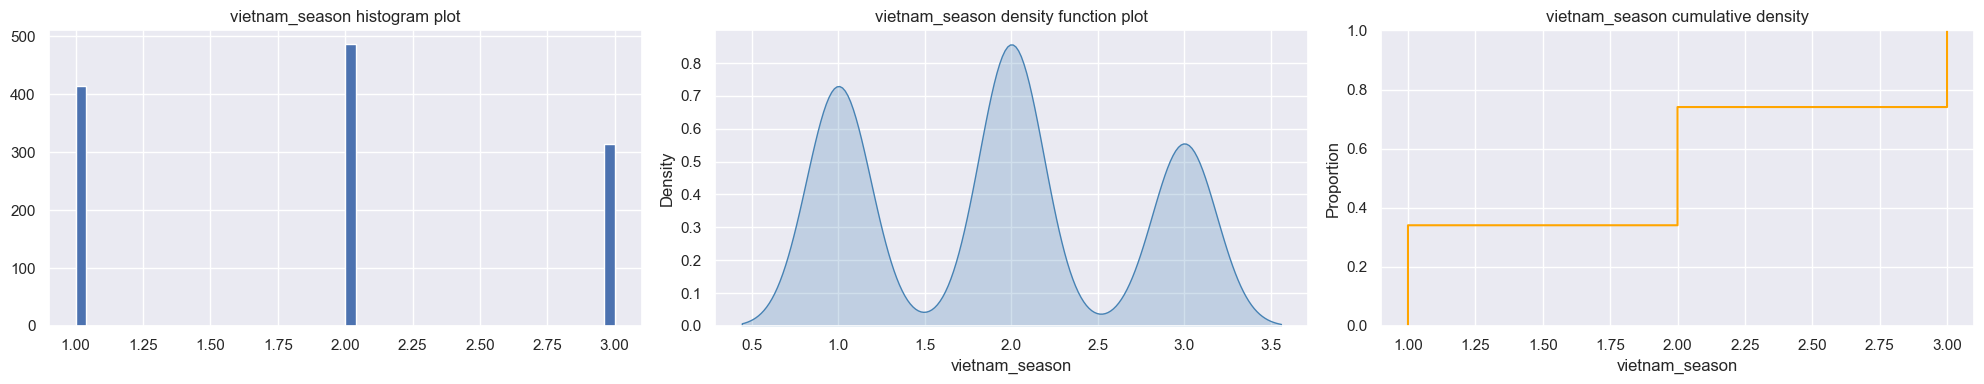

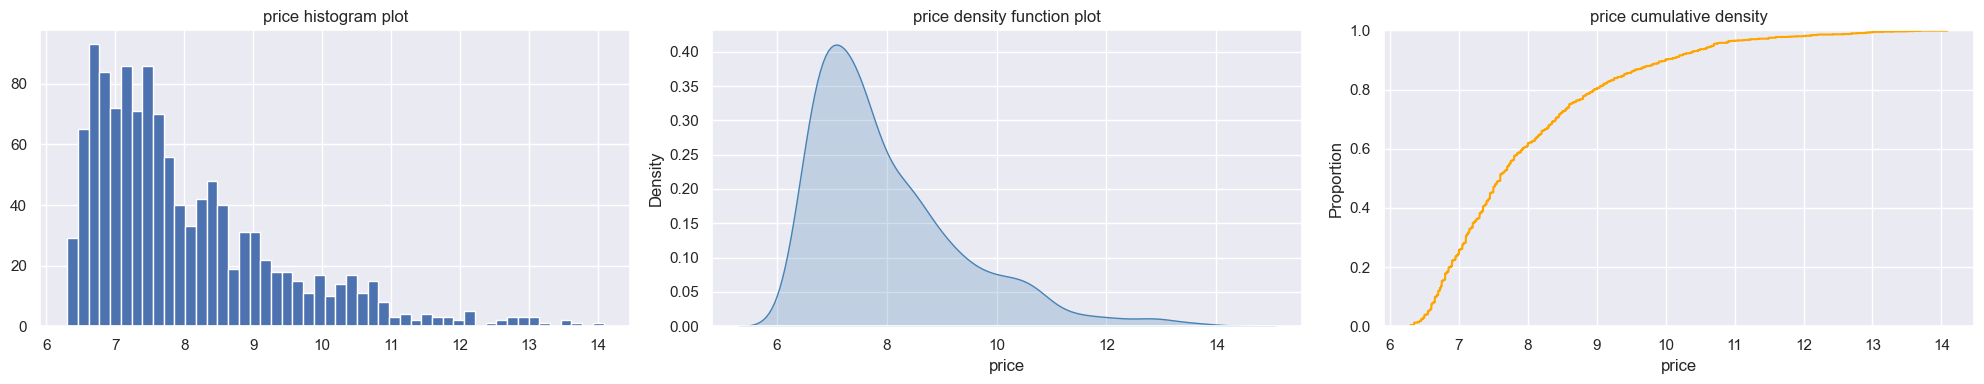

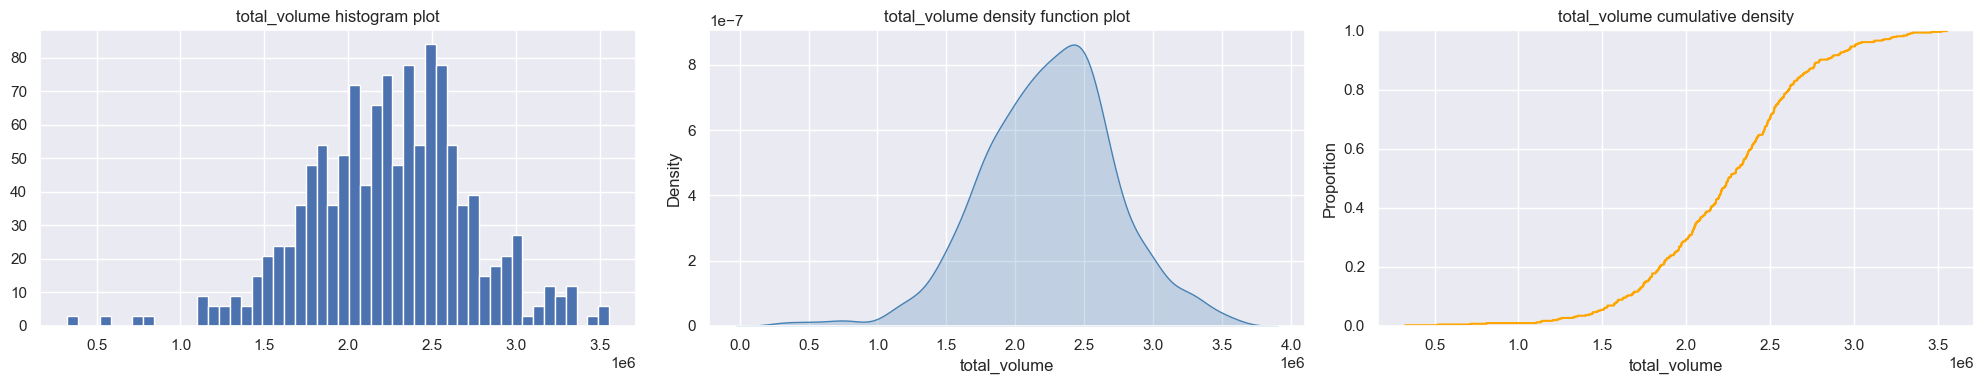

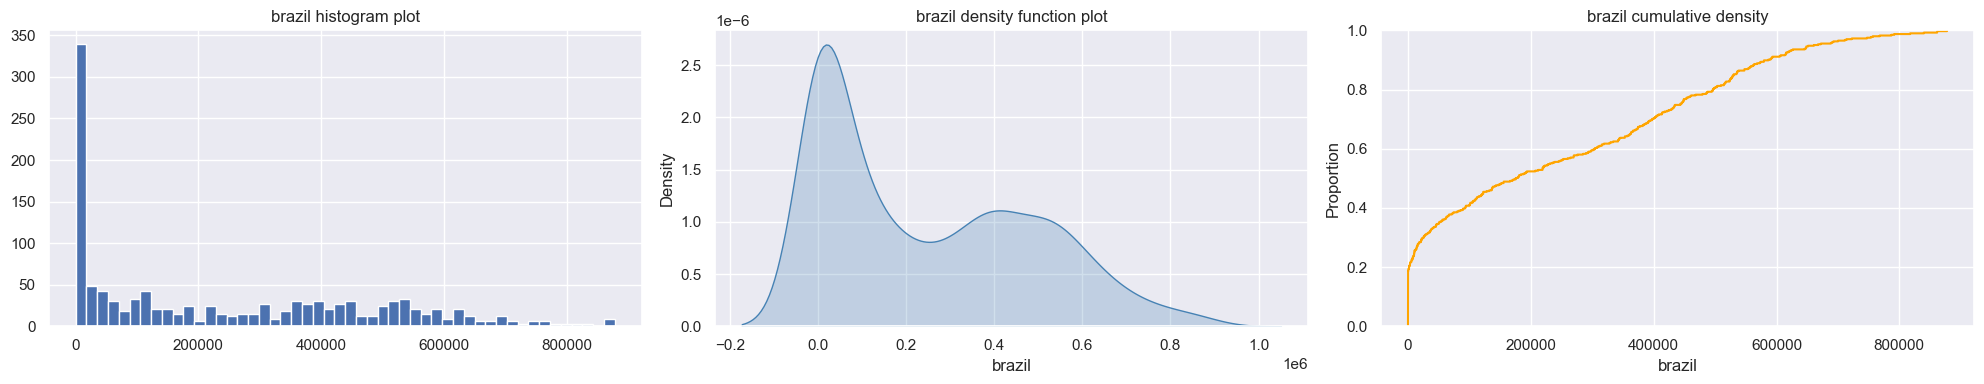

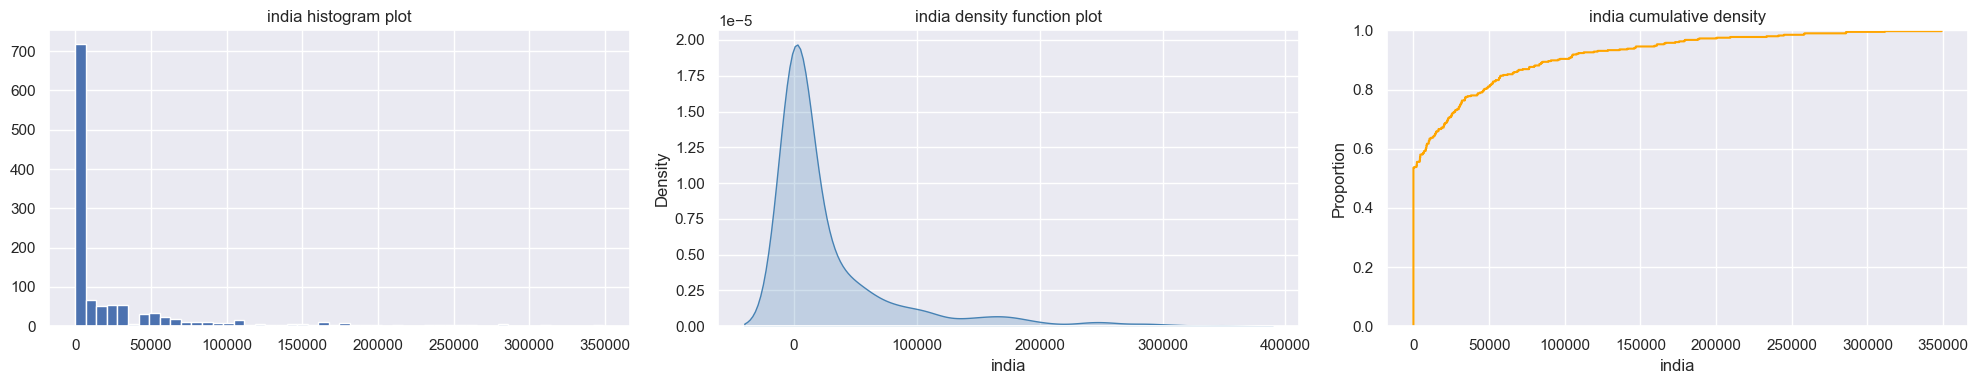

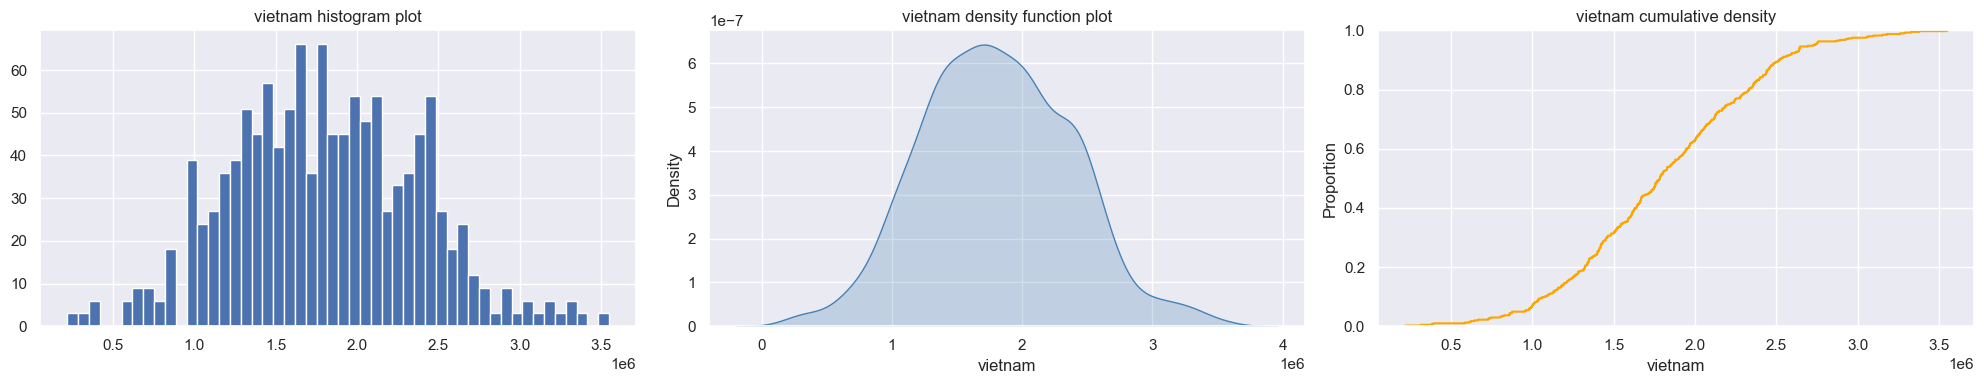

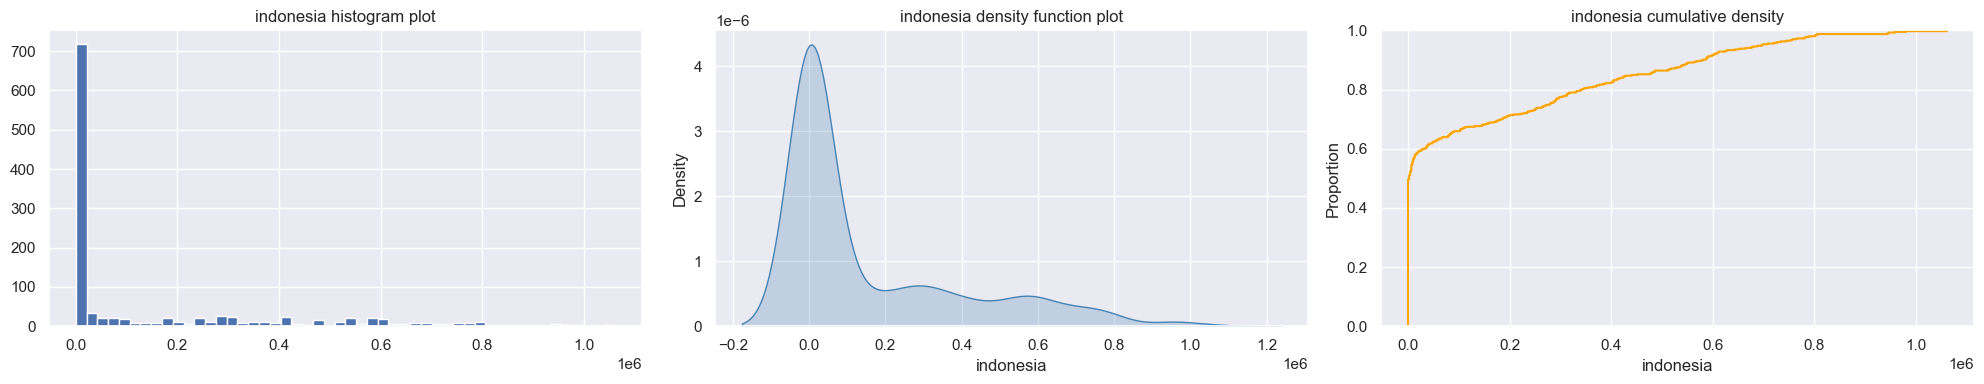

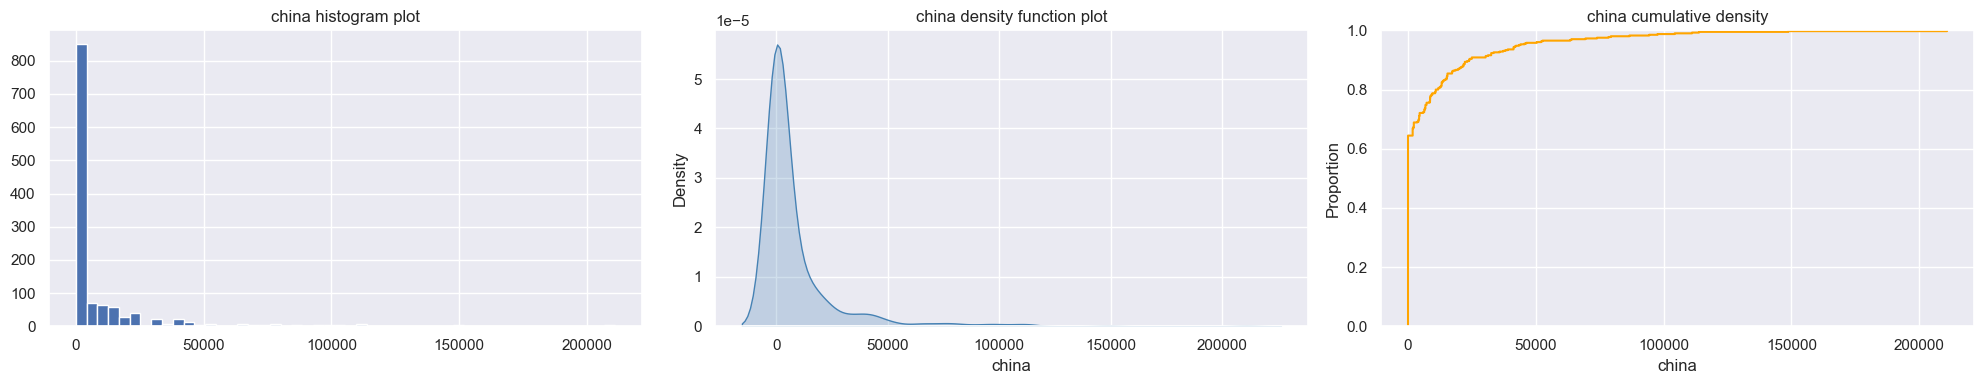

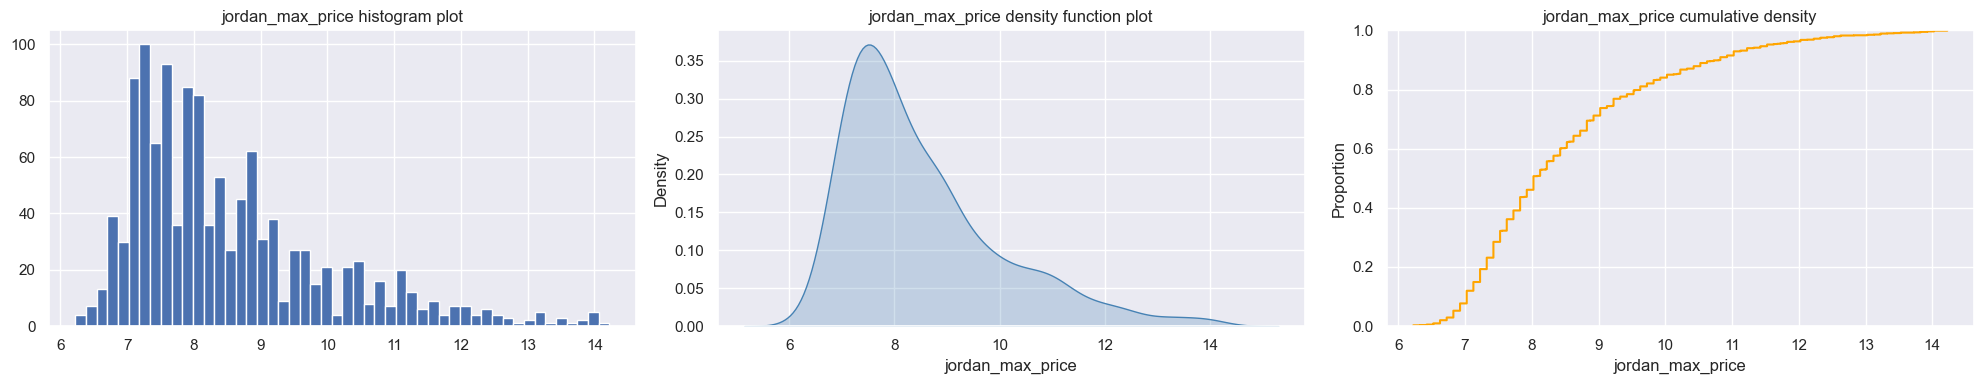

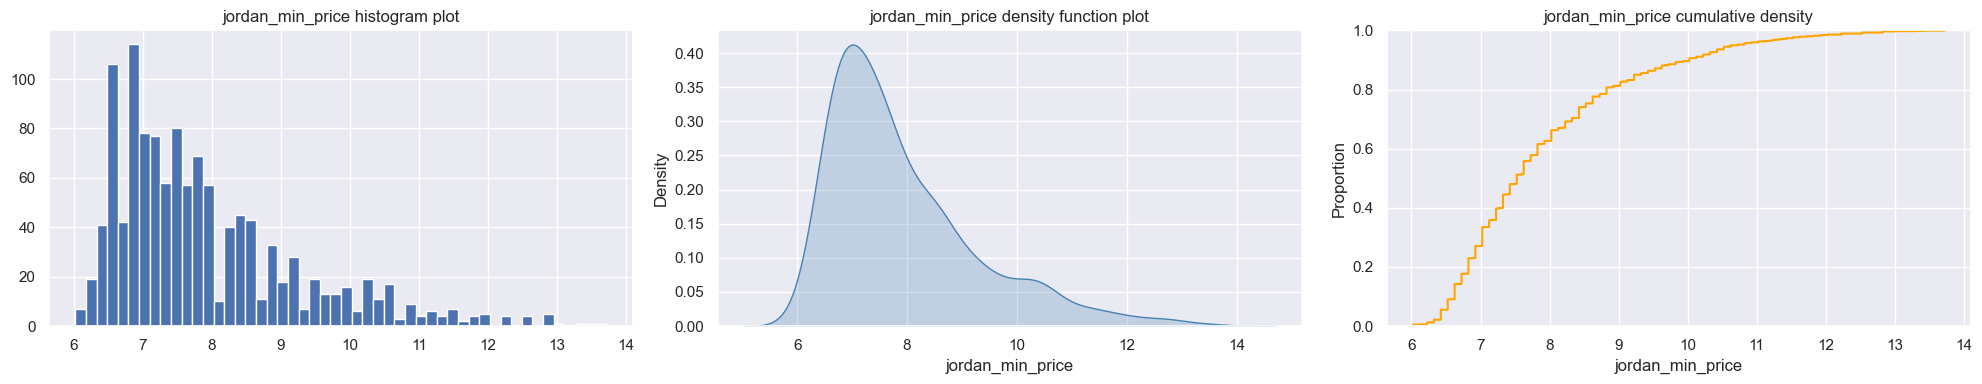

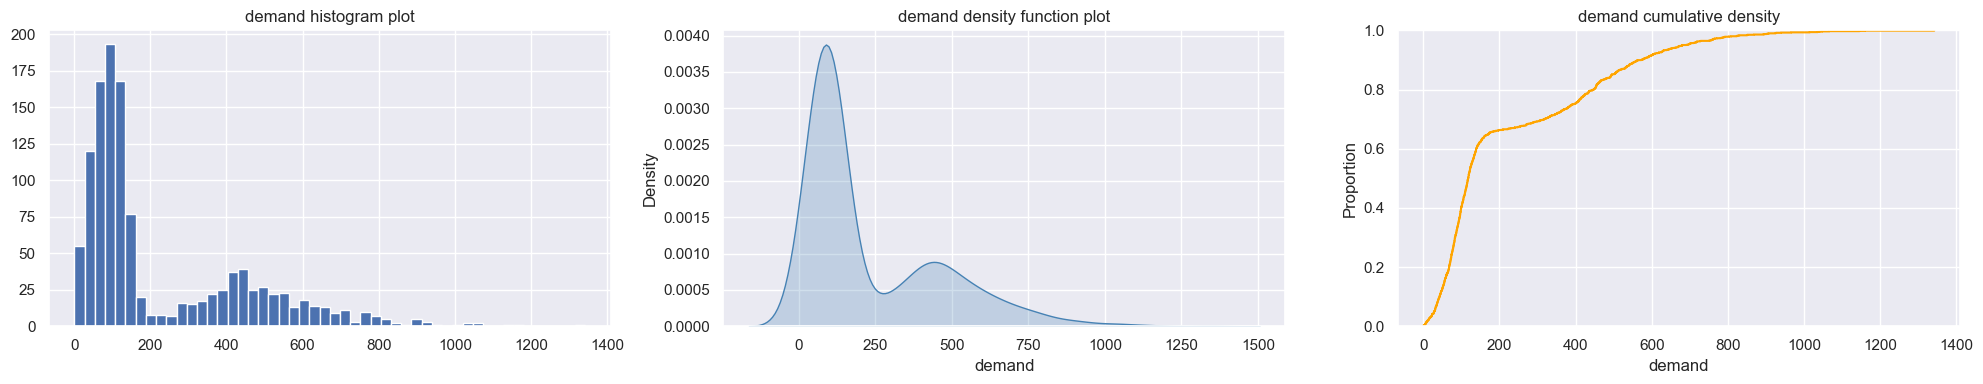

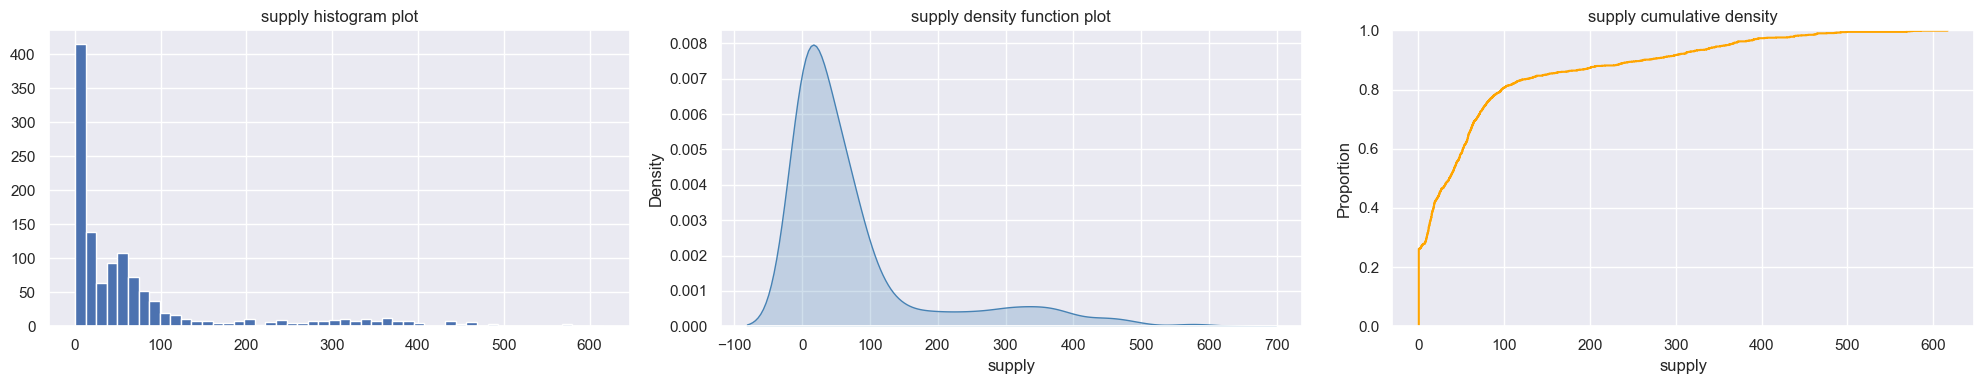

In [24]:
for col in numerical_cols:
    plt.figure(figsize=(20, 4))

    plt.subplot(1, 3, 1)
    df_copy[col].hist(bins=50)
    plt.title(f"{col} histogram plot")

    plt.subplot(1, 3, 2)
    sns.kdeplot(df_copy[col], fill=True, color='steelblue')
    plt.title(f"{col} density function plot")

    plt.subplot(1, 3, 3)
    sns.ecdfplot(df_copy[col], color='orange')
    plt.title(f"{col} cumulative density")

    plt.tight_layout()
    plt.show()

* *Visalizing numerical_cols --> ordinal_cols:*

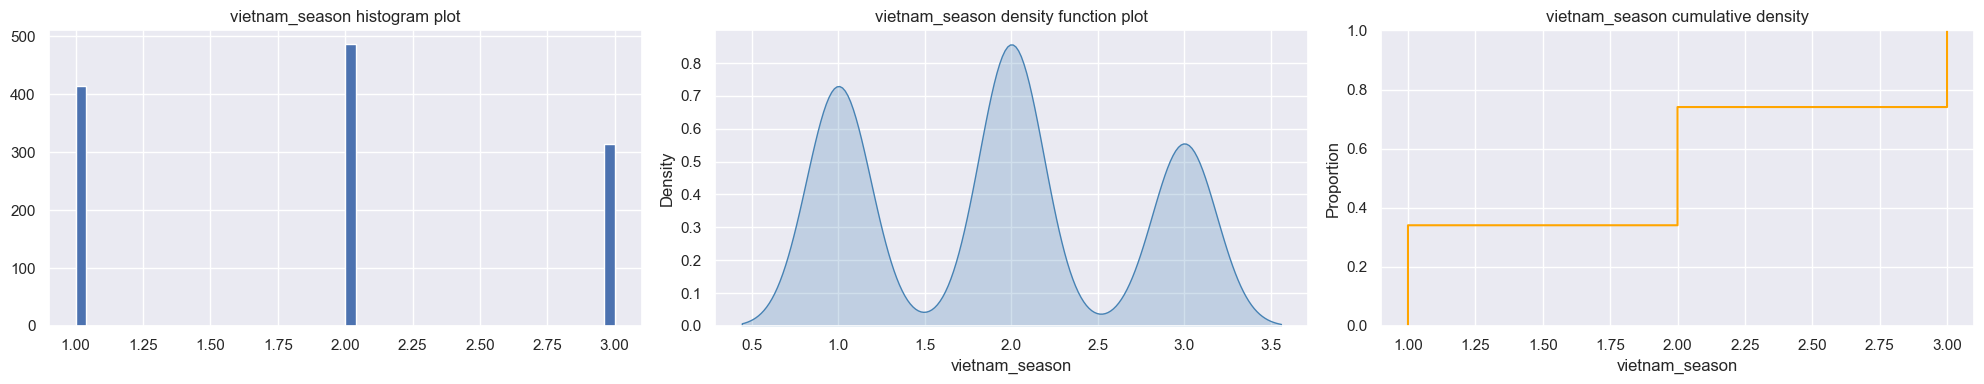

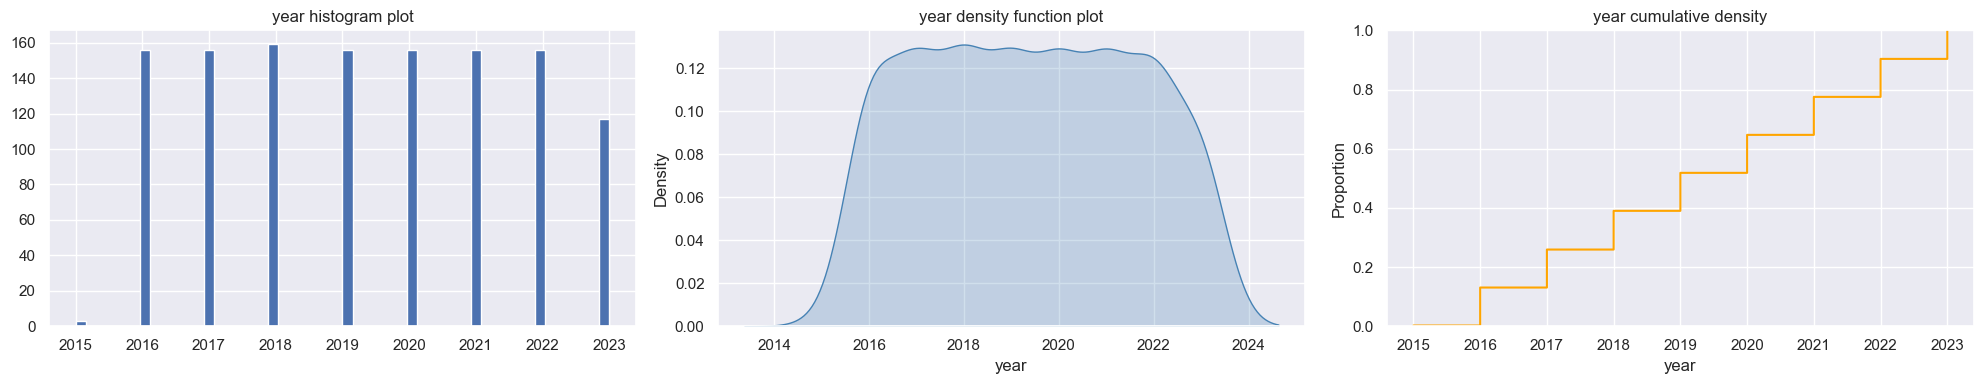

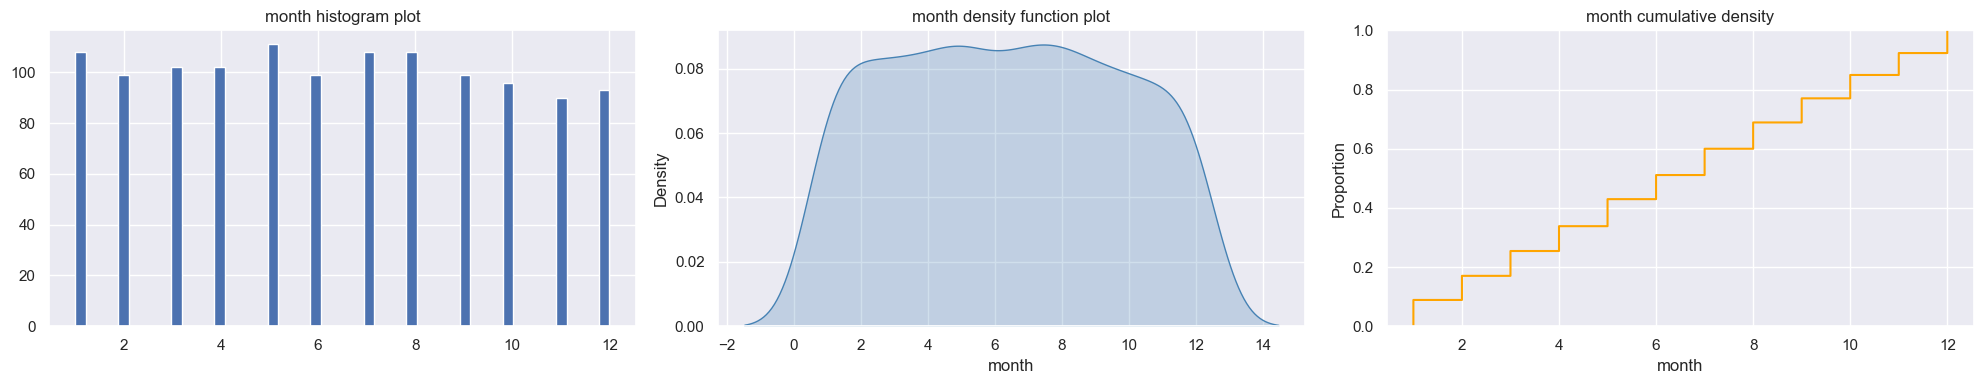

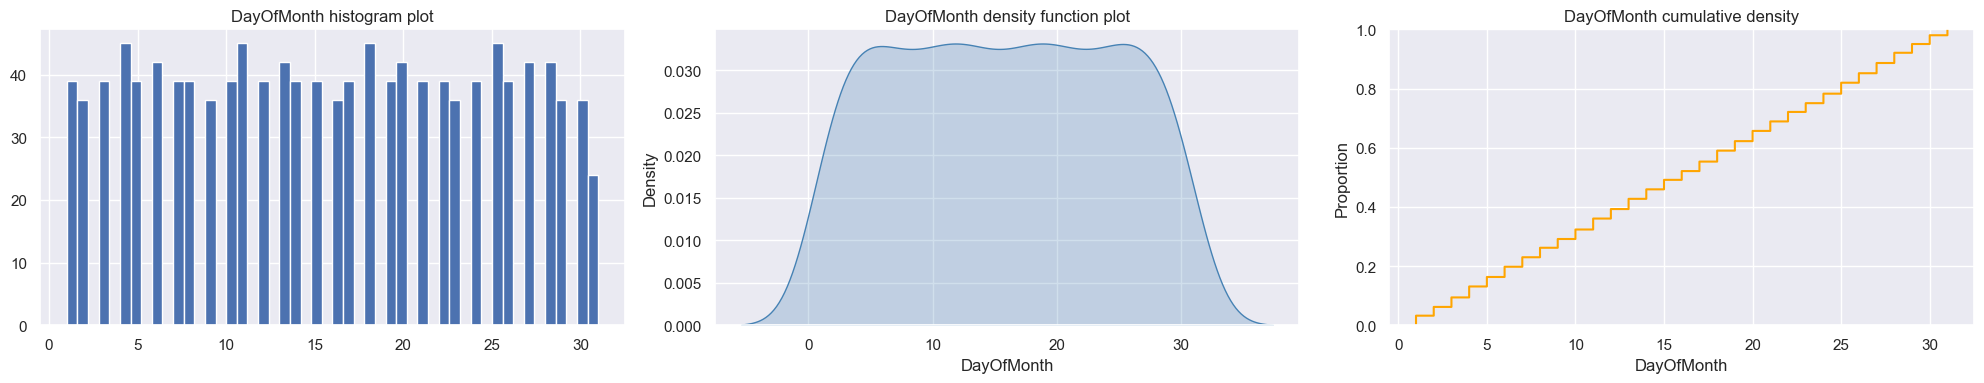

In [25]:
for col in ordinal_cols:
    plt.figure(figsize=(20, 4))

    plt.subplot(1, 3, 1)
    df_copy[col].hist(bins=50)
    plt.title(f"{col} histogram plot")

    plt.subplot(1, 3, 2)
    sns.kdeplot(df_copy[col], fill=True, color='steelblue')
    plt.title(f"{col} density function plot")

    plt.subplot(1, 3, 3)
    sns.ecdfplot(df_copy[col], color='orange')
    plt.title(f"{col} cumulative density")

    plt.tight_layout()
    plt.show()

### *Categorical features :*

* *categorical_cols basic summary statistics :*

In [26]:
df[categorical_cols].describe().T

,count,unique,top,freq
p_color,1215,3,green,405


* *Visalizing categorical_cols:*

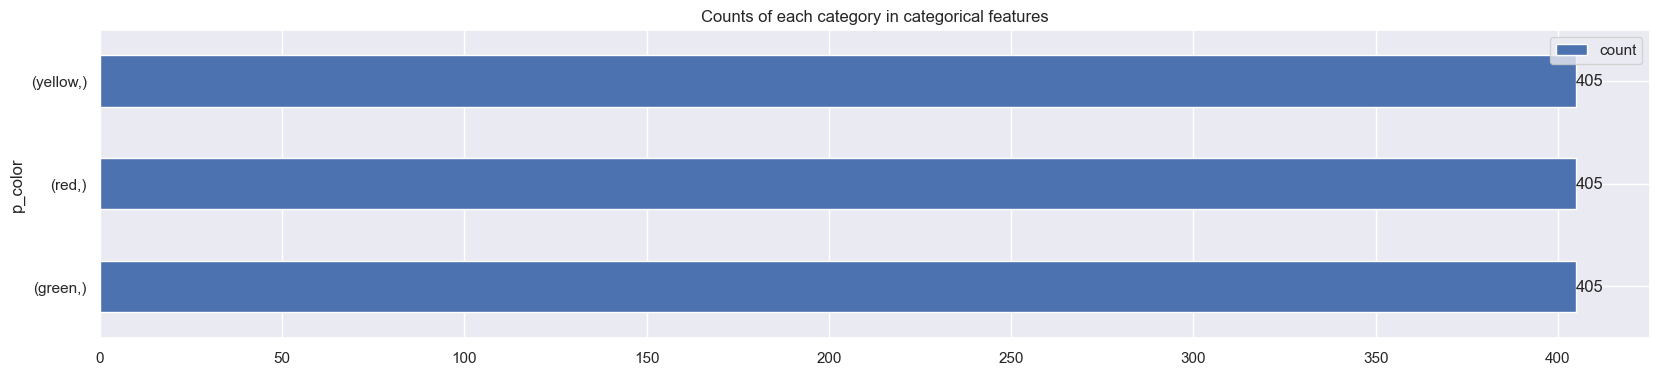

In [27]:
ax=df[categorical_cols].value_counts().to_frame().rename(columns={0:"Counts"}).plot(kind="barh",figsize=(20,4),title="Counts of each category in categorical features")
ax.bar_label(ax.containers[0]);

### *boolean features :*

* *boolean_cols basic summary statistics :*

In [28]:
df[boolean_cols].describe()

,brazil_season,indonesia_season,india_season,china_season
count,1215,1215,1215,1215
unique,2,2,2,2
top,False,False,False,False
freq,690,903,912,801


* *Visalizing boolean_cols:*

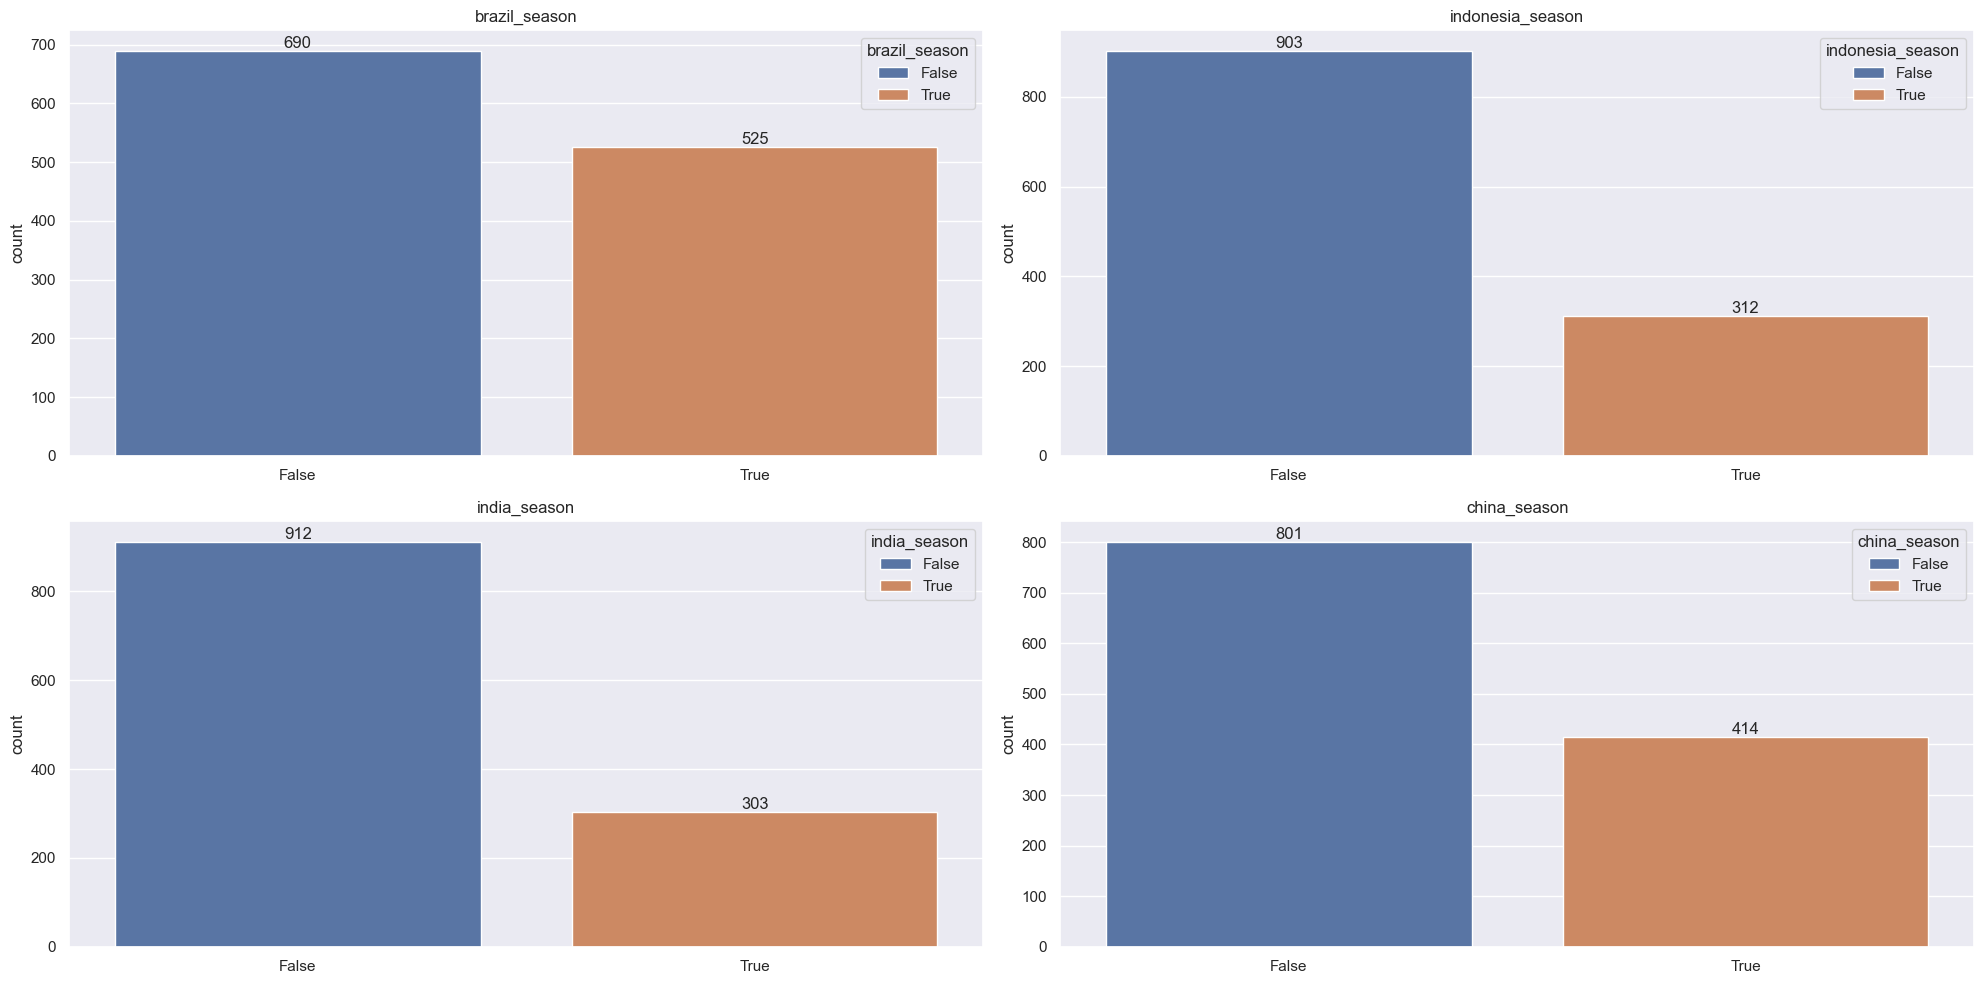

In [29]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df, x="brazil_season", ax=ax1,hue='brazil_season')
ax1.set_title("brazil_season")
ax1.set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container)

ax2 = fig.add_subplot(gs[0, 1])
Area_order=['A','B','C','D','E','F']
sns.countplot(data=df, x="indonesia_season", ax=ax2,hue='indonesia_season')
ax2.set_title("indonesia_season")
ax2.set_xlabel("")
for container in ax2.containers:
    ax2.bar_label(container)

ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x="india_season", ax=ax3,hue='india_season')
ax3.set_title("india_season")
ax3.set_xlabel("")
for container in ax3.containers:
    ax3.bar_label(container) 


ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x="china_season", ax=ax4,hue='china_season')
ax4.set_title("china_season")
ax4.set_xlabel("")
for container in ax4.containers:
    ax4.bar_label(container)  


plt.tight_layout()
plt.show()

---
* *Seasons Overlaping :*  
*We will find out how seasons overlap with each other*

In [30]:
df_copy2=df_copy.copy()
df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']]=df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']].astype("int")
df_seasons=df_copy2[['month','vietnam_season','brazil_season','india_season','china_season','indonesia_season']]

In [31]:
df_seasons.groupby(['month','vietnam_season','india_season','china_season','indonesia_season','brazil_season']).count()

Empty DataFrame
Columns: []
Index: [(1, 2, 0, 0, 0, 0), (2, 2, 0, 0, 0, 0), (3, 3, 0, 0, 0, 0), (3, 3, 0, 0, 0, 1), (4, 3, 0, 0, 0, 1), (5, 3, 0, 0, 0, 1), (5, 3, 0, 1, 1, 1), (6, 1, 0, 1, 1, 1), (7, 1, 0, 1, 1, 1), (7, 1, 1, 1, 1, 1), (8, 1, 1, 1, 0, 0), (8, 1, 1, 1, 1, 1), (9, 1, 1, 0, 0, 0), (9, 1, 1, 1, 0, 0), (10, 2, 0, 0, 0, 0), (10, 2, 1, 0, 0, 0), (11, 2, 0, 0, 0, 0), (12, 2, 0, 0, 0, 0)]

* *Visualizing Seasons Overlaping-heatmap :*  

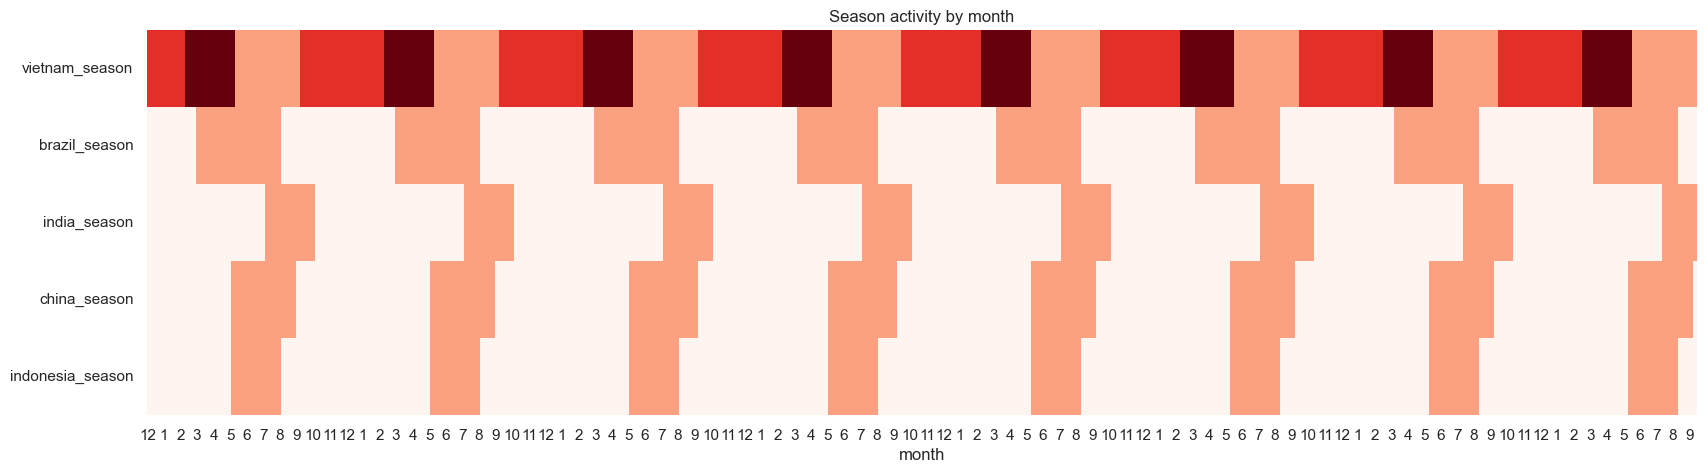

In [32]:
import seaborn as sns
plt.subplots(figsize=(20,5))
sns.heatmap(df_seasons.set_index('month').T, cmap="Reds", cbar=False)
plt.title("Season activity by month")
plt.show()


* *Visualizing Seasons Overlaping-barplots :*  

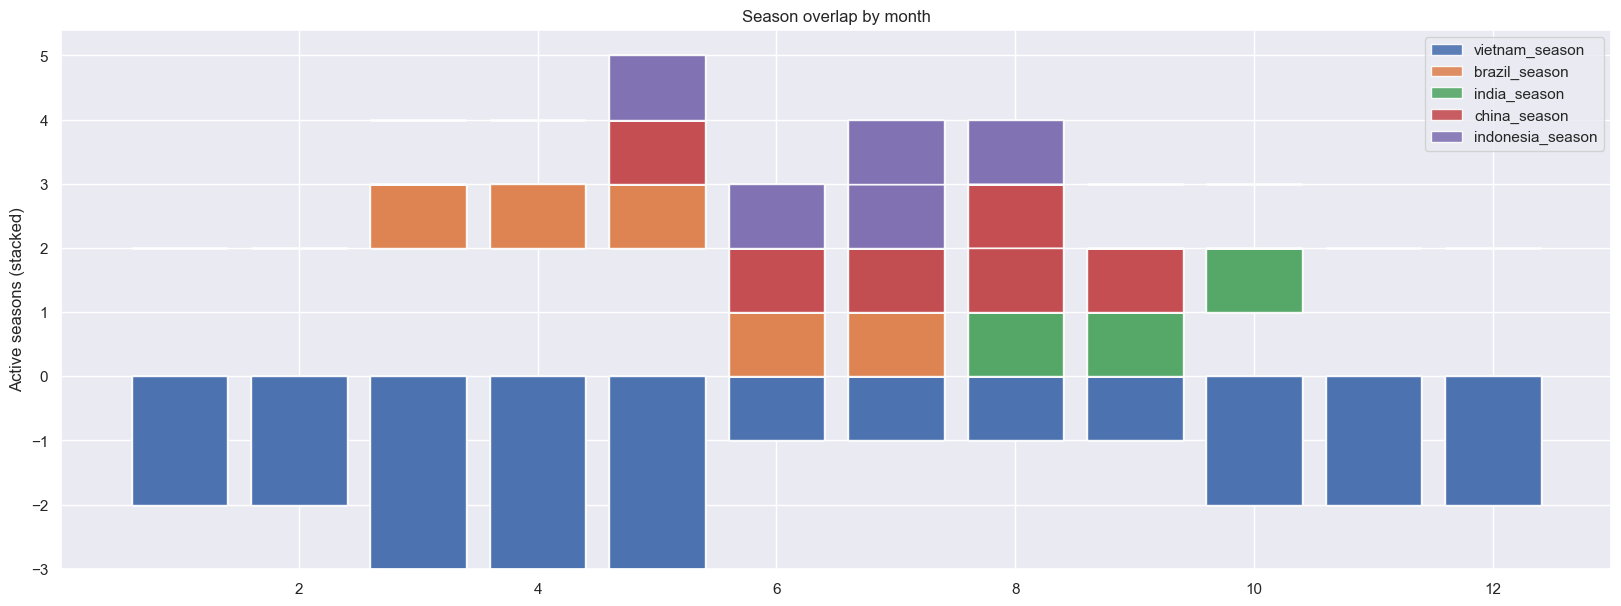

In [33]:
fig, ax = plt.subplots(figsize=(20, 7))
for i, season in enumerate(['vietnam_season', 'brazil_season', 'india_season','china_season','indonesia_season']):
    ax.bar(df_seasons['month'], df_seasons[season], bottom=df_seasons.iloc[:, 1:i+1].sum(axis=1)-df_seasons[season],
          label=season, alpha=0.9)

ax.legend()
ax.set_ylabel("Active seasons (stacked)")
#ax.set_yticklabels("")

plt.title("Season overlap by month")
plt.show()

## *Inferential statistics*  
* *Hypothesis testing*

*Checking the Target feature-Price- normality*

In [23]:
from scipy.stats import shapiro
import scipy.stats as stats   
def normaly_distibuted_check(data,column):
    from scipy.stats import shapiro
    stat, p = shapiro(data[column])
    print(f"W = {stat:.3f}, p = {p:.3f}")
    if p < 0.05:
        print("Reject H₀ → distribution is not normal")
    else:
        print("Fail to reject H₀ → distribution is compatible with normality")
  
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))   
    sns.boxplot(data=data, x=column, ax=axes[0])
    axes[0].set_title(f'{column} Boxplot')  
    sns.histplot(data=data, x=column, ax=axes[1])
    axes[1].set_title(f'{column} histogram') 
    stats.probplot(data[column], dist="norm", plot=plt)
    axes[2].set_title(f'{column} qq-plot')   

W = 0.877, p = 0.000
Reject H₀ → distribution is not normal


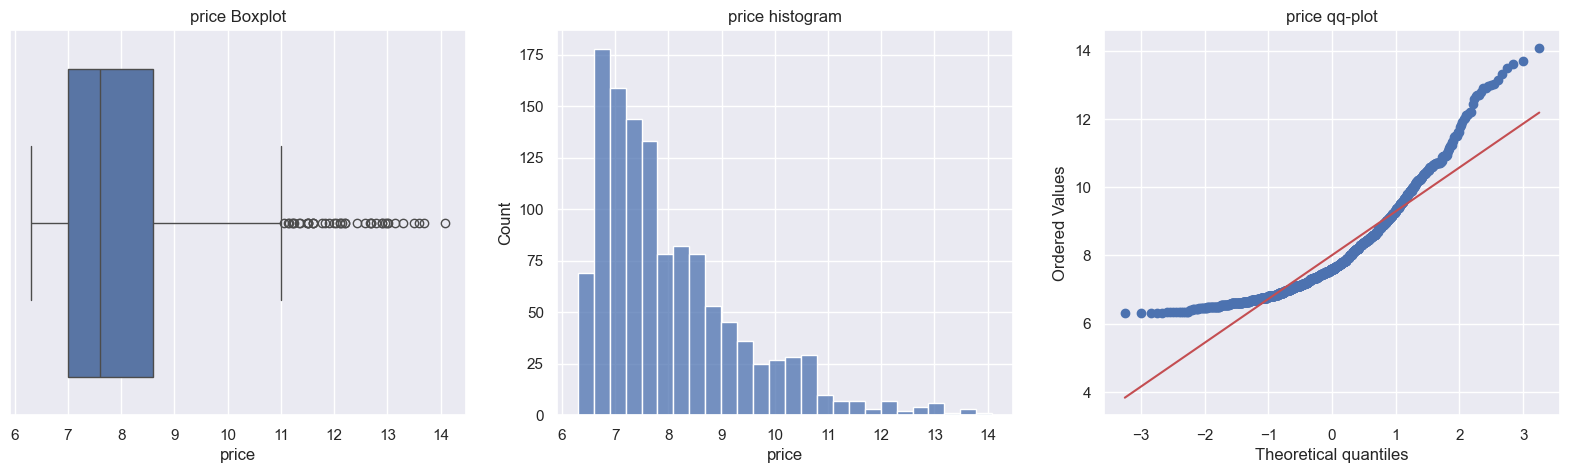

In [24]:
normaly_distibuted_check(data=df_copy,column="price")

---

* *When looking at the week_start_dt feature , we see that the data is weekly basis for each p_color*

In [34]:
df_ts=df_copy2.drop('week_end_dt',axis=1)
df_ts=df_ts.rename(columns={'week_start_dt': 'Date'})
df_ts=df_ts.set_index('Date')
df_ts.head()

,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,DayOfMonth
Date,,,,,,,,,,,,,,,,,,,,
2015-12-28,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,6.625,6.325,0.50,0.5,12,2015,28
2015-12-28,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.525,7.125,0.51,0.5,12,2015,28
2015-12-28,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.425,7.025,16.55,0.5,12,2015,28
2016-01-04,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.525,7.025,271.16,0.5,1,2016,4
2016-01-04,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.625,7.125,42.33,0.5,1,2016,4


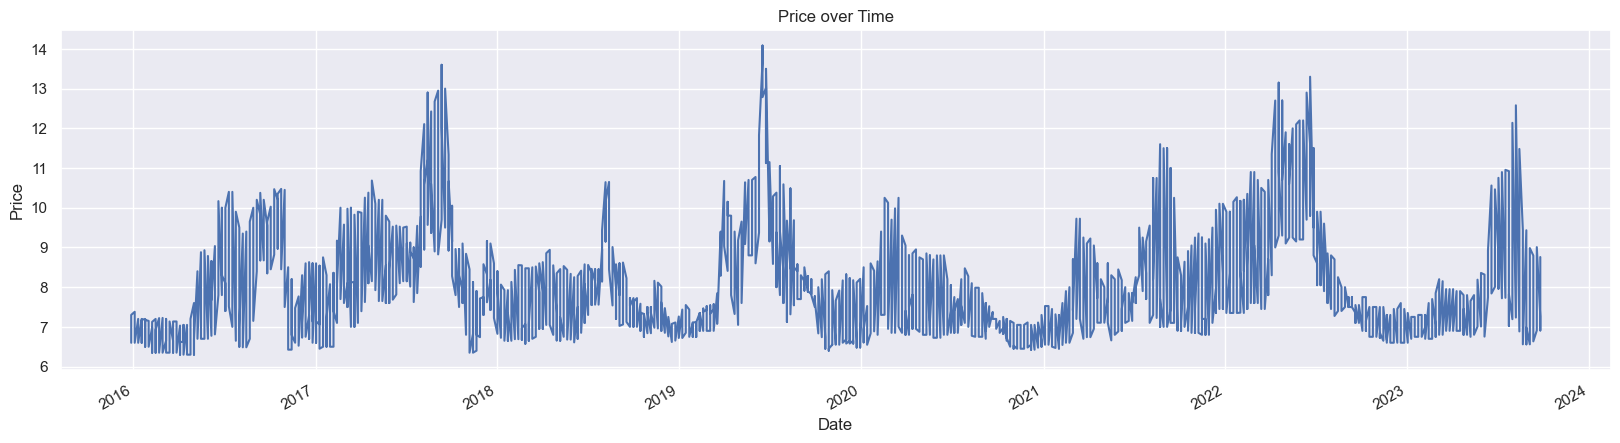

In [261]:
plt.subplots(figsize=(20,5))
color_map = {'red': 'red', 'yellow': 'yellow', 'green': 'green'}
colors = [color_map[cat] for cat in df_ts['p_color']]
df_ts["price"].plot(title="Price over Time",ylabel="Price",xlabel="Date");

Features developments:  
---> Before diving in , lets look at the features developments during the past time -yearly basis

*Features developments quick explaination*

* *Rolling :Computes statistics over a fixed-size moving window.*  
  * *Example : (weidow =3)*

|       |              |                               |
| -------------- | ------------------------------------- | ----------------------------------------------------------- |
| 1 | NaN   |  # first two values have no full window yet                    |
| 2 | NaN        |                     |
| 3 | 2          |  # (1+2+3)/3                                 |
| 4 | 3 | # (2+3+4)/3    | 
| 5  | 4       |    # (3+4+5)/3 




* *Expanding : Calculates a cumulative (expanding) statistic Every new point includes all previous data up to that point*
   * *example:*


|       |              |                               |
| -------------- | ------------------------------------- | ----------------------------------------------------------- |
| 1 | 1   |  (1)                    |
| 2 | 1.5        |  (1+2)/2                   |
| 3 | 2                   |  (1+2+3)/3                                |
| 4 | 2.5 | # ... |
|   | 3       |           |

* *ewm : Exponentially Weighted Moving (EWM) statistics give more weight to recent data and less weight to older data.*  
   * *If alpha = 0.01, then weights decay slowly (long memory).*  
   * *If alpha = 0.5, they decay quickly (short memory).*  
   * *adjust=False means --> :Weights are applied recursively*  
   * *Use when: You want a smoothed trend that reacts slowly or quickly depending on alpha.*

* *ewm(span=span) : Exponential Moving Weighted Average*  
   * *instead of directly setting alpha, you can define a span, which pandas converts internally to an equivalent alpha,So span acts like a “window length” but with exponentially decaying weights.*  
   * *Use when: You want to specify a “memory length” (like 10 periods) instead of directly setting the decay rate.*

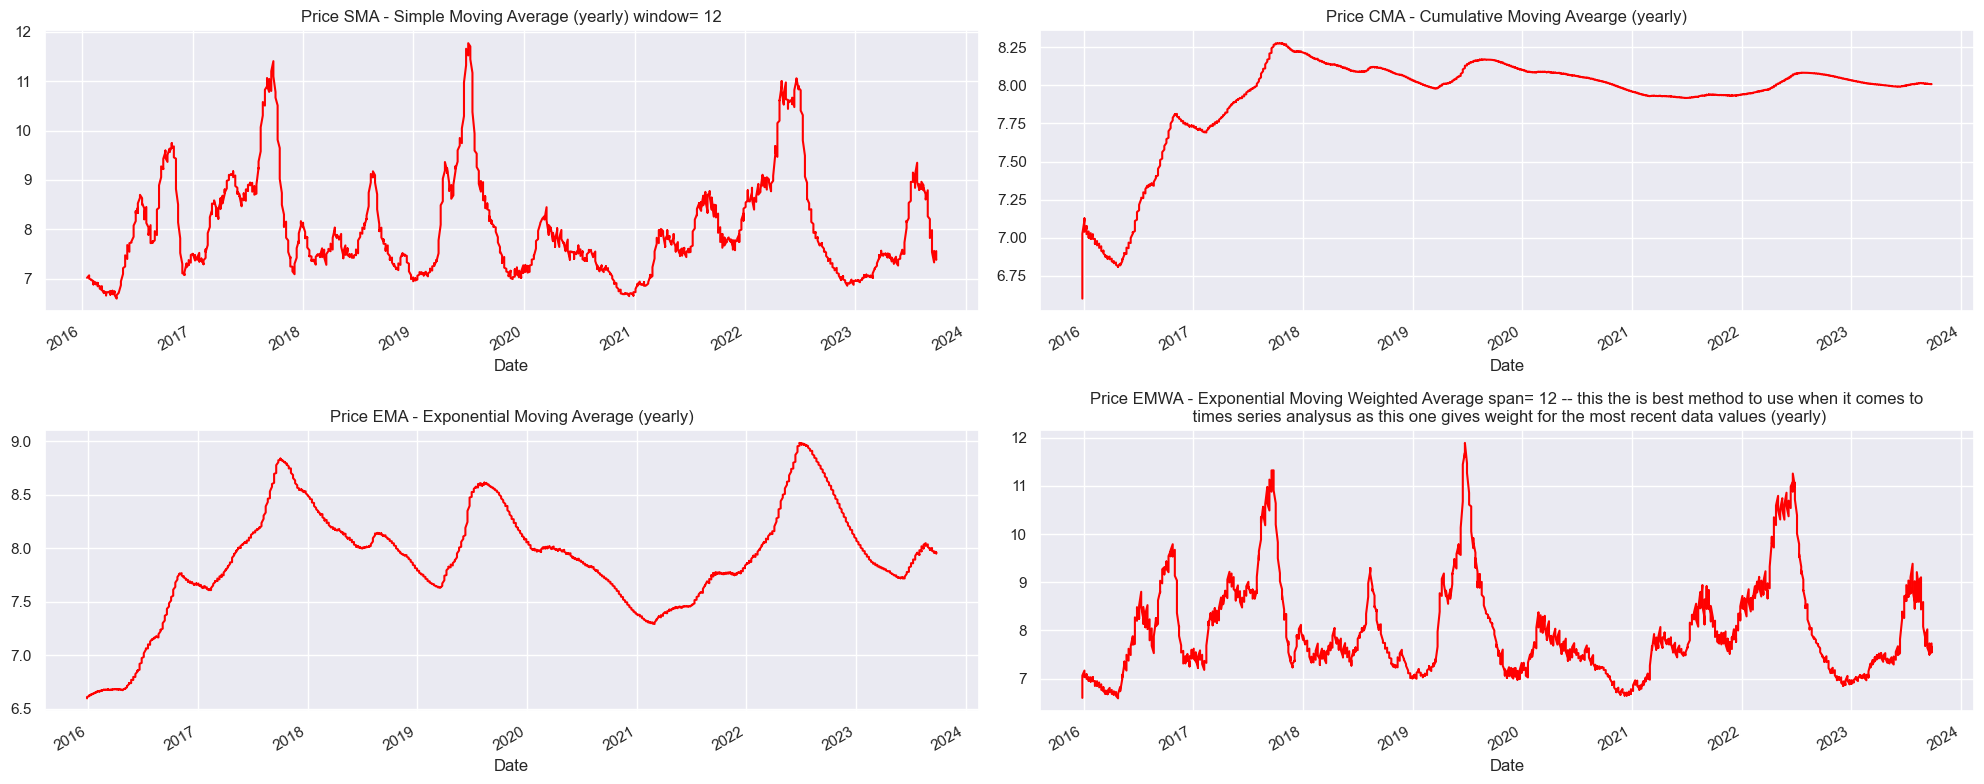

In [262]:
feature_development(Dataset=df_ts,Numericaltarget="price",rolling_window=12,span_n=12)

*'min','mean','max' price by year and month :*

In [263]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Basic Yearly Price Stats</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Basic Monthly Price Stats</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Top 10 Price by Year & Month</h4>
        {df3}
    </div>

</div>
""".format(
    df1=pd.DataFrame(df_copy.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df2=pd.DataFrame(df_copy.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df3=pd.DataFrame(df_copy.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))


year,min,mean,max
2015,6.599075,7.024995,7.300575
2016,6.299625,7.743472,10.474745
2017,6.349525,8.721290,13.600505
2018,6.575525,7.658701,10.650240
2019,6.400310,8.309906,14.084590
2020,6.424740,7.394565,10.250070
2021,6.445080,7.830989,11.600420
2022,6.600445,8.615491,13.300160
2023,6.560342,7.759264,12.579919
month,min,mean,max


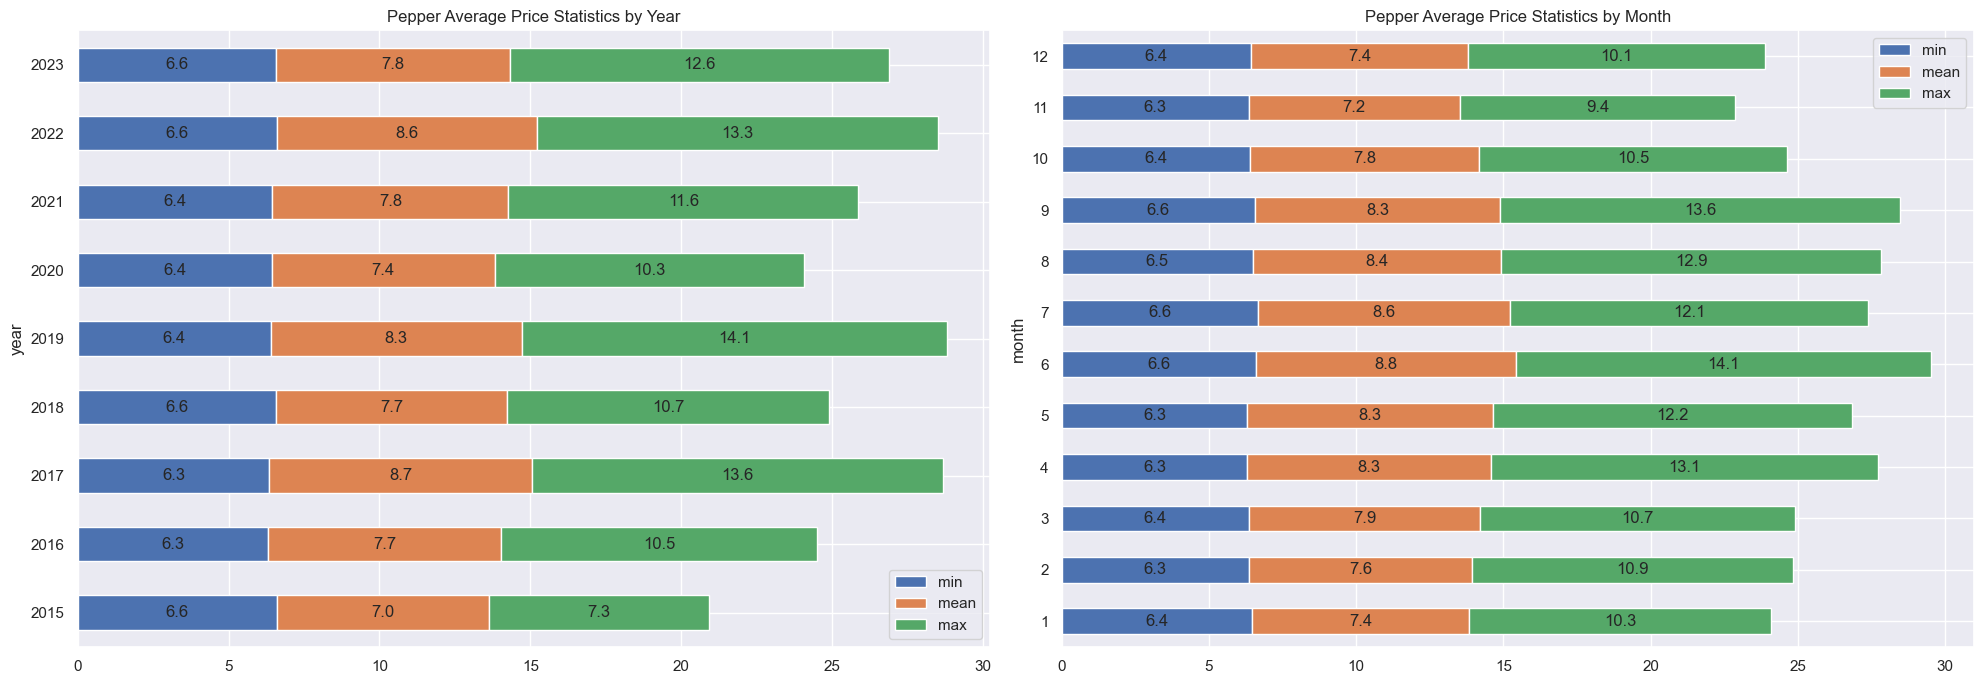

In [264]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

pd.DataFrame(df_copy.groupby("year")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    title='Pepper Average Price Statistics by Year'
)

pd.DataFrame(df_copy.groupby("month")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax2,
    title='Pepper Average Price Statistics by Month'
)


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')

plt.tight_layout()
plt.show()


---

* *We will seperate the dataset based on the p_color and apply resmapling*

In [265]:
df_ts_red=df_ts[df_ts["p_color"]=="red"]
df_ts_green=df_ts[df_ts["p_color"]=="green"]
df_ts_yellow=df_ts[df_ts["p_color"]=="yellow"]

*Visualize the monthly/yearly and weekly price resampling by color*

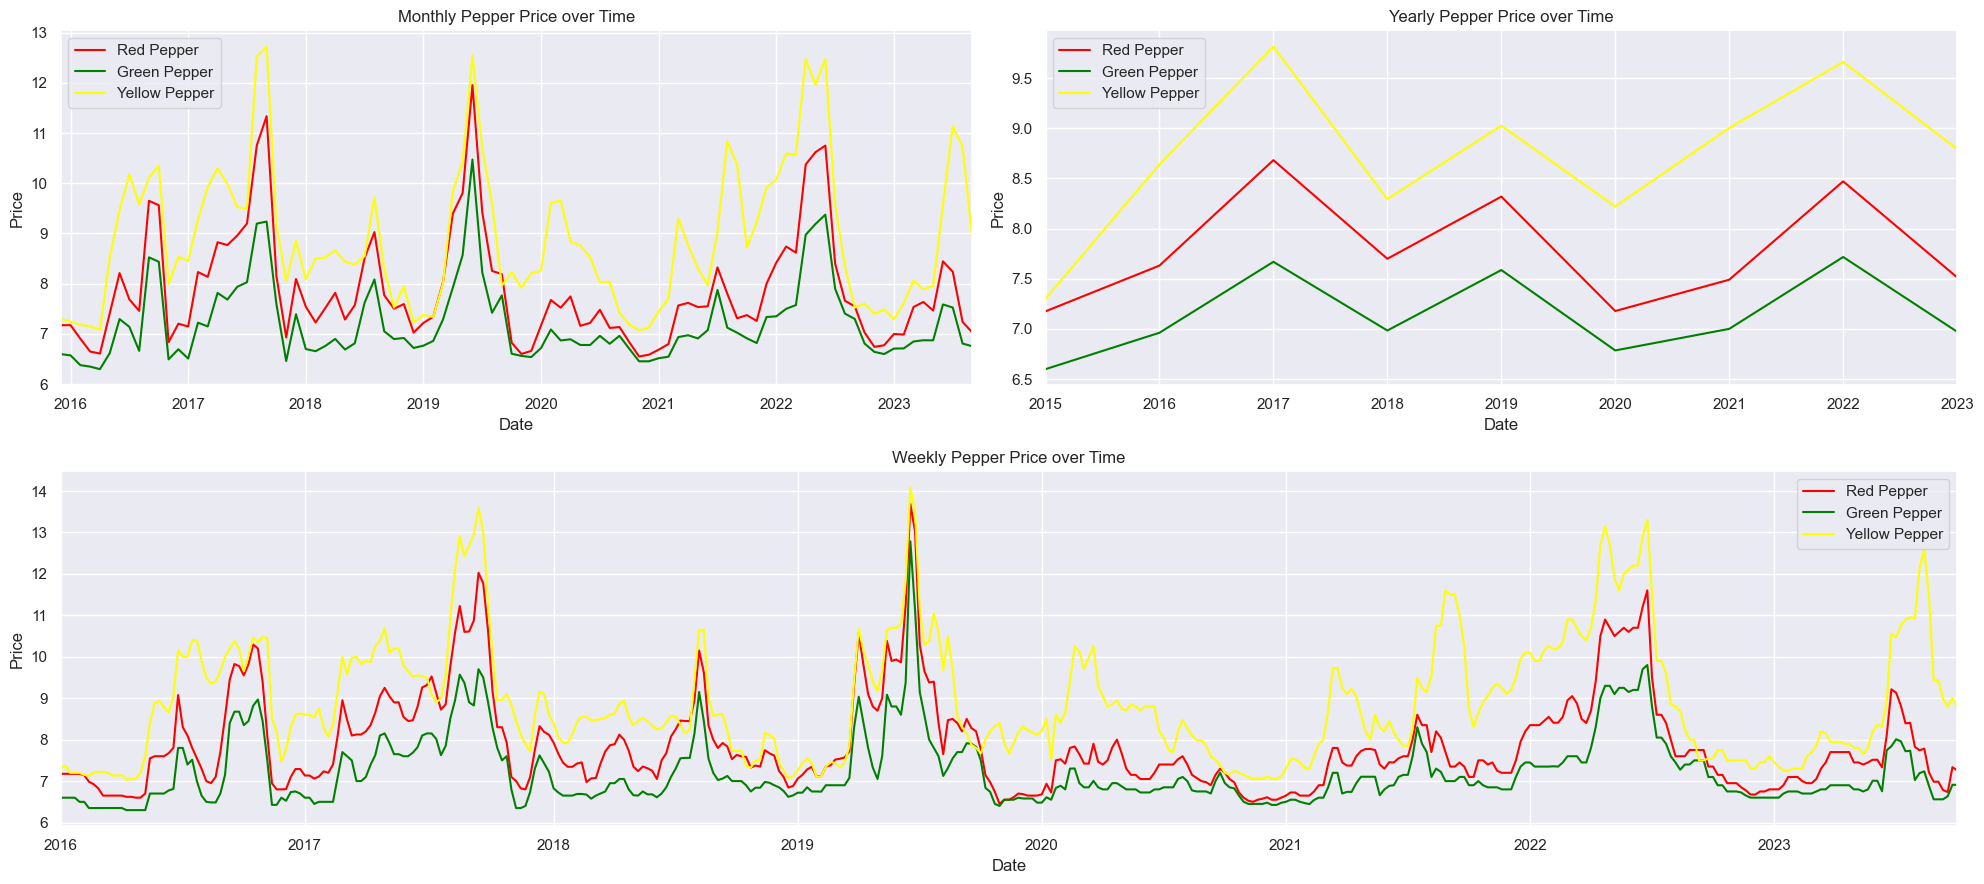

In [266]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 9))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
df_ts_red["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax1.set_title("Monthly Pepper Price over Time")
ax1.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])

ax2 = fig.add_subplot(gs[0, 1])
df_ts_red["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax2.set_title("Yearly Pepper Price over Time")
ax2.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])

ax3 = fig.add_subplot(gs[1, :])
df_ts_red["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax3.set_title("Weekly Pepper Price over Time")
ax3.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])


plt.tight_layout()
plt.show()

*Note :*  
*We can clearly see that the yellow Pepper has the highest mean price by month,year and week then Red Pepper and lastly Green Pepper*

*Price EDA by p_color :*

In [267]:
M_resample_df_red=df_ts_red["price"].resample('M').mean().to_frame()
M_resample_df_green=df_ts_green["price"].resample('M').mean().to_frame()
M_resample_df_yellow=df_ts_yellow["price"].resample('M').mean().to_frame()
#################################################################################
W_resample_df_red=df_ts_red["price"].resample('W').mean().to_frame()
W_resample_df_green=df_ts_green["price"].resample('W').mean().to_frame()
W_resample_df_yellow=df_ts_yellow["price"].resample('W').mean().to_frame()

In [268]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Monthly Price discribtion Stats between Bell Pepper colors</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Weekly Price discribtion Stats between Bell Pepper colors</h4>
        {df2}
    </div>

</div>
""".format(
    df1=pd.concat([M_resample_df_red.describe().rename(columns={'price':'red_price'}),
           M_resample_df_green.describe().rename(columns={'price':'green_price'}),
           M_resample_df_yellow.describe().rename(columns={'price':'yellow_price'})],axis=1).reset_index().to_html(classes='dataframe', index=False),
    df2=pd.concat([W_resample_df_red.describe().rename(columns={'price':'red_price'}),
           W_resample_df_green.describe().rename(columns={'price':'green_price'}),
           W_resample_df_yellow.describe().rename(columns={'price':'yellow_price'})],axis=1).reset_index().to_html(classes='dataframe', index=False)
)
display(HTML(html))

index,red_price,green_price,yellow_price
count,94.000000,94.000000,94.000000
mean,7.877891,7.213010,8.918563
std,1.116662,0.780305,1.411048
min,6.552164,6.299625,7.072058
25%,7.164904,6.707040,7.950263
50%,7.546867,6.911742,8.531525
75%,8.251077,7.519952,9.704393
max,11.953655,10.471418,12.721365
index,red_price,green_price,yellow_price
count,405.000000,405.000000,405.000000


---

* *Red Pepper Price*

*'min','mean','max' price of Red Bell Pepper color by year and month :*

In [269]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Red Bell Pepper Basic Yearly Price Stats</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Red Bell Pepper Basic Monthly Price Stats</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Red Bell Pepper Top 10 Price by Year & Month</h4>
        {df3}
    </div>

</div>
""".format(
    df1=pd.DataFrame(df_ts_red.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df2=pd.DataFrame(df_ts_red.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df3=pd.DataFrame(df_ts_red.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))


year,min,mean,max
2015,7.175335,7.175335,7.175335
2016,6.600165,7.630899,10.295265
2017,6.799845,8.681479,12.025475
2018,6.845210,7.698913,10.150460
2019,6.449990,8.317951,13.685380
2020,6.500410,7.178296,7.999920
2021,6.649570,7.490333,8.599950
2022,6.674985,8.470593,11.600320
2023,6.735184,7.513677,9.213480
month,min,mean,max


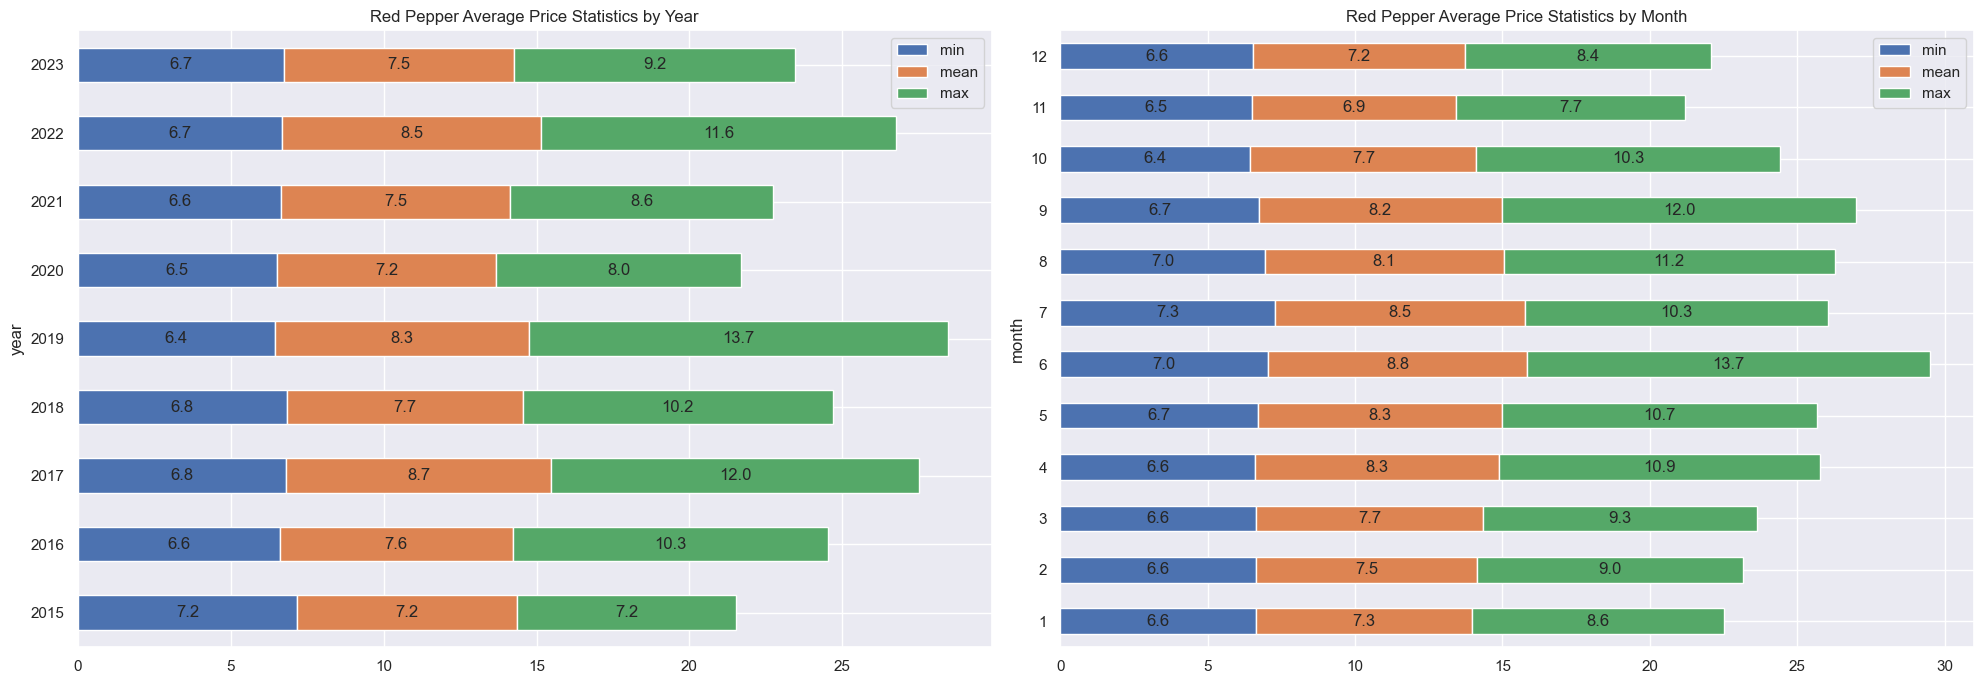

In [270]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

pd.DataFrame(df_ts_red.groupby("year")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    title='Red Pepper Average Price Statistics by Year'
)

pd.DataFrame(df_ts_red.groupby("month")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax2,
    title='Red Pepper Average Price Statistics by Month'
)


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')

plt.tight_layout()
plt.show()


*Red Bell Pepper Features developments:*

In [271]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Simple Moving Average</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Cummulative Moving Average</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Average</h4>
        {df3}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Weighted Average</h4>
        {df4}
    </div>

</div>
""".format(
    df1=M_resample_df_red.rolling(window=3).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df2=M_resample_df_red.expanding().mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df3=M_resample_df_red.ewm(alpha=.01,adjust=False).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df4=M_resample_df_red.ewm(span=12).mean().reset_index().head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))


Date,price
2015-12-31,NaN
2016-01-31,NaN
2016-02-29,7.085538
2016-03-31,6.910388
2016-04-30,6.722054
2016-05-31,6.890048
2016-06-30,7.410883
2016-07-31,7.769941
2016-08-31,7.786665
2016-09-30,8.265973


*Red Bell Pepper Features developments Visualization:*

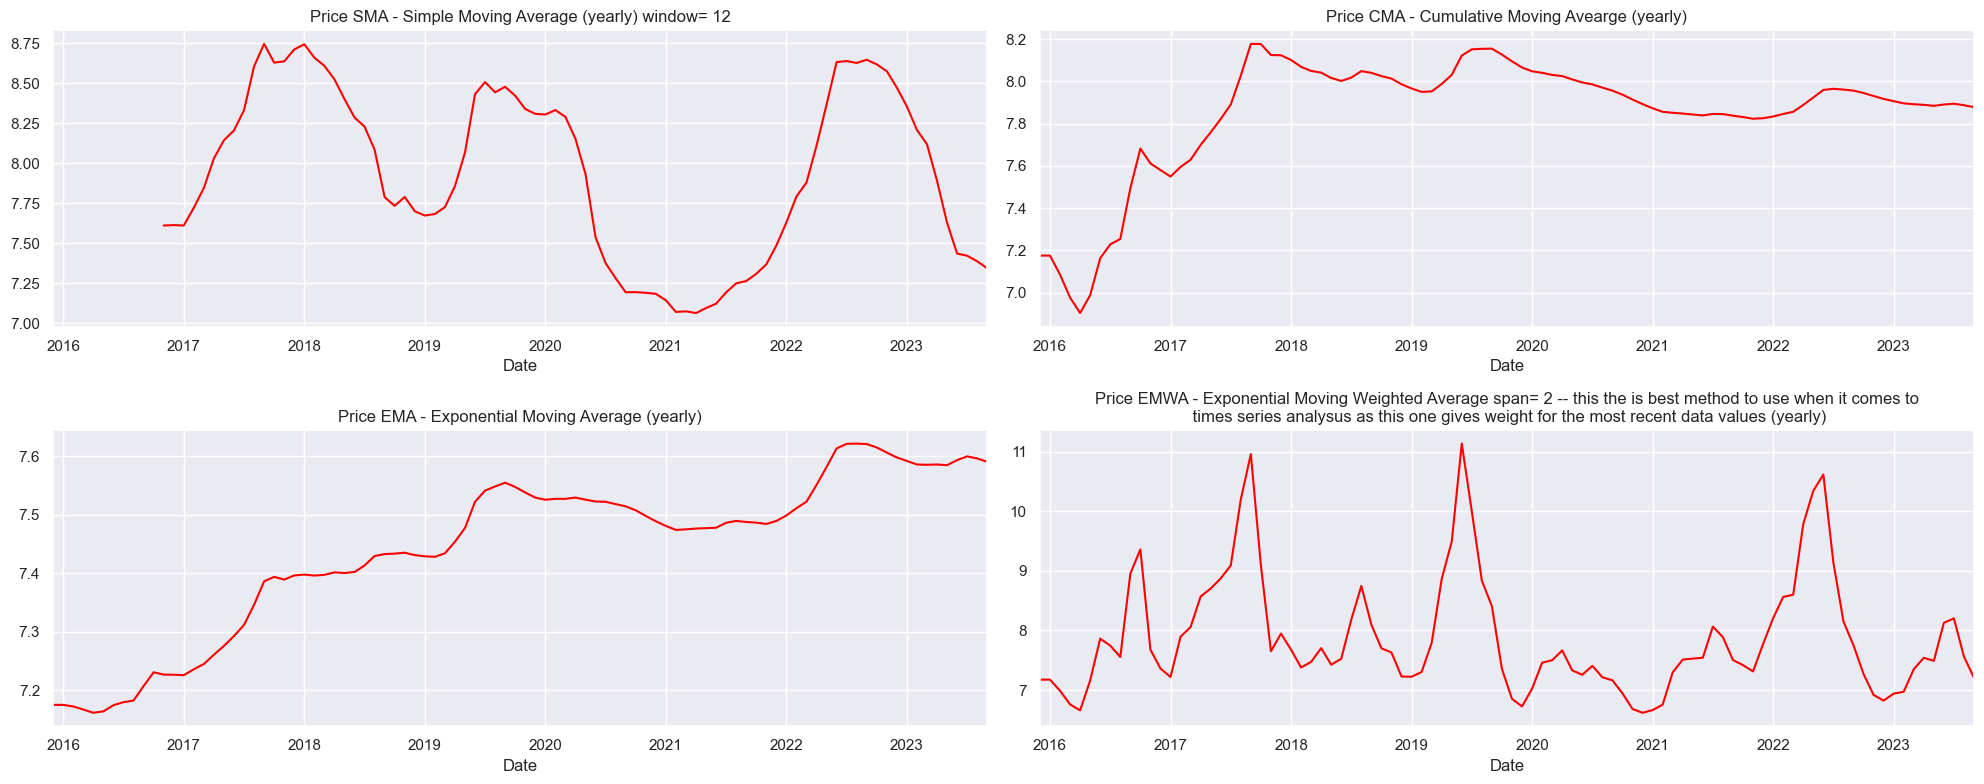

In [272]:
feature_development(Dataset=M_resample_df_red,Numericaltarget="price",rolling_window=12,span_n=2)

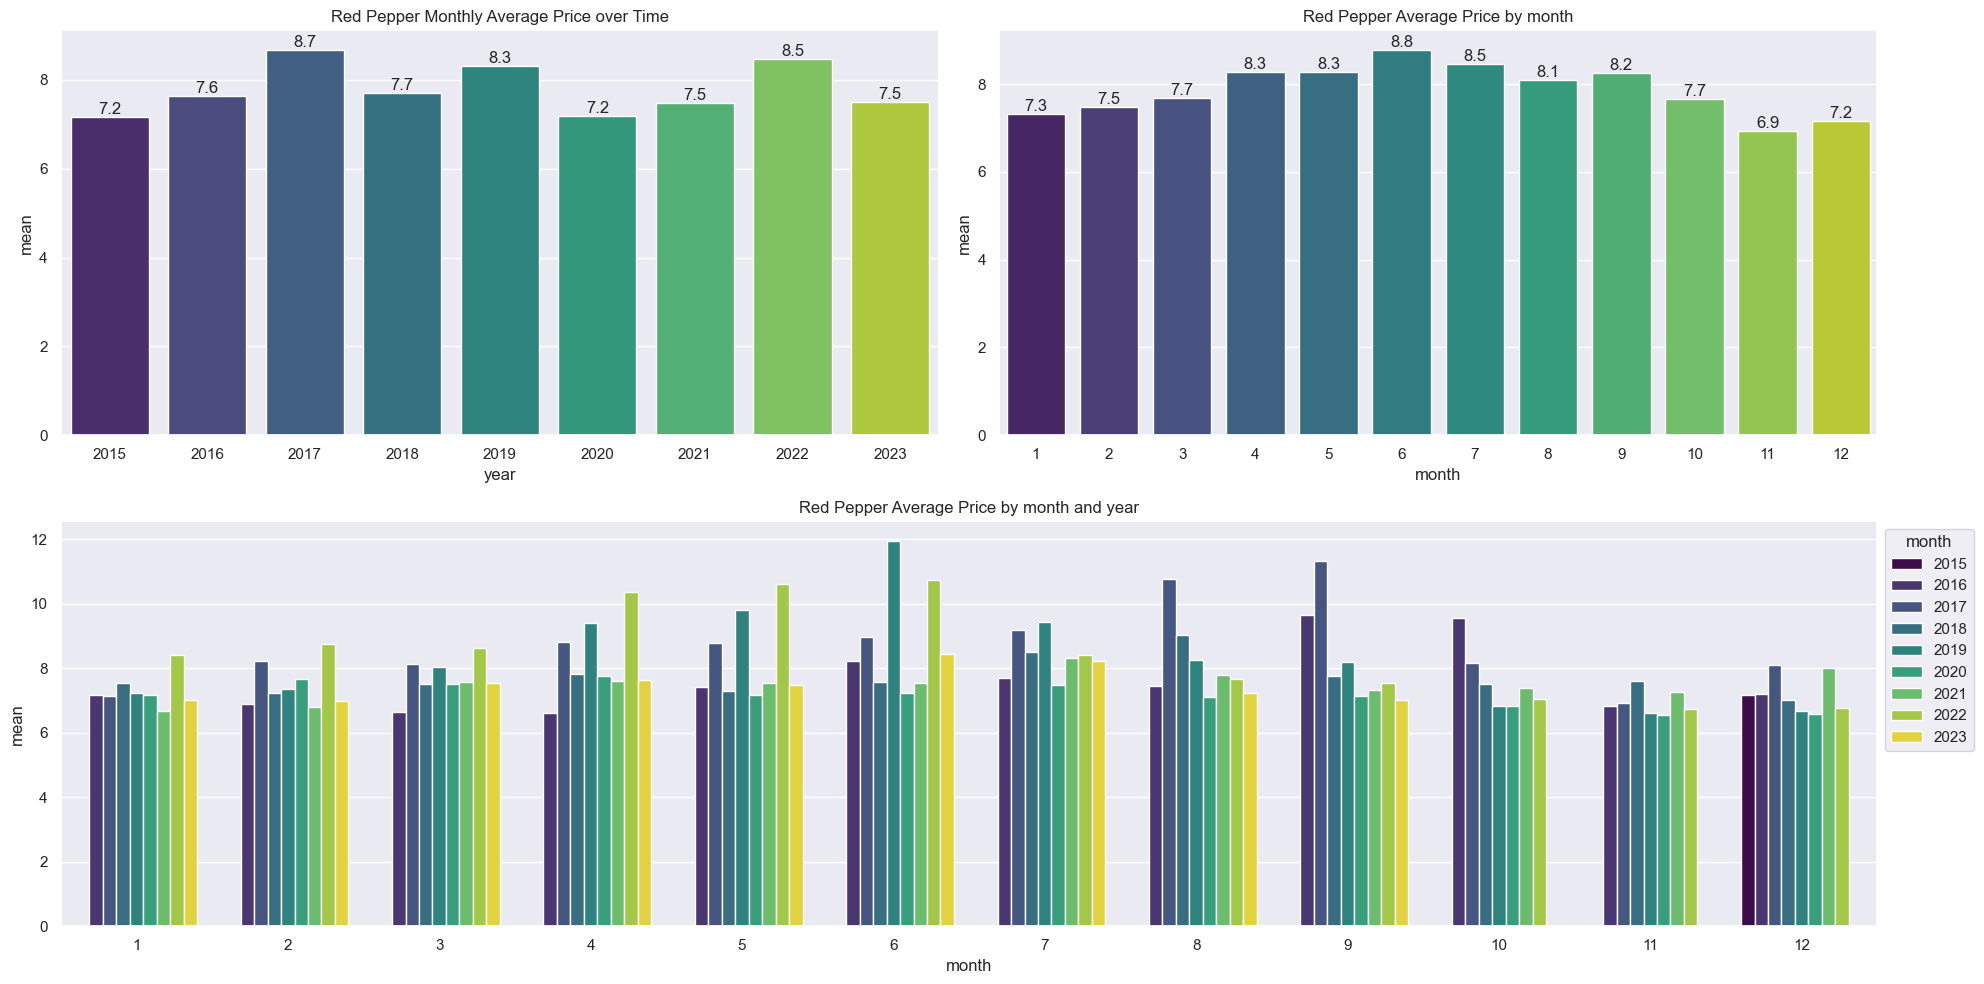

In [273]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1=sns.barplot(data=pd.DataFrame(df_ts_red.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index(),
            x="year", y="mean", palette="viridis",errorbar=None)
ax1.set_title("Red Pepper Monthly Average Price over Time")
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type="edge")

ax2 = fig.add_subplot(gs[0, 1])
ax2=sns.barplot(data=pd.DataFrame(df_ts_red.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", palette="viridis",errorbar=None)
ax2.set_title("Red Pepper Average Price by month")
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type="edge")

ax3 = fig.add_subplot(gs[1, :])
ax3=sns.barplot(data=pd.DataFrame(df_ts_red.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", hue="year",palette="viridis",legend=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
ax3.set_title("Red Pepper Average Price by month and year")
ax3.legend(title='month', bbox_to_anchor=(1, 1), loc='upper left');


plt.tight_layout()
plt.show()

---

* *Green Pepper Price*

*'min','mean','max' price of Green Bell Pepper color by year and month :*

In [276]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Green Bell Pepper Basic Yearly Price Stats</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Green Bell Pepper Basic Monthly Price Stats</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Green Bell Pepper Top 10 Price by Year & Month</h4>
        {df3}
    </div>

</div>
""".format(
    df1=pd.DataFrame(df_ts_green.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df2=pd.DataFrame(df_ts_green.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df3=pd.DataFrame(df_ts_green.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))


year,min,mean,max
2015,6.599075,6.599075,6.599075
2016,6.299625,6.961848,8.969815
2017,6.349525,7.668789,9.699975
2018,6.575525,6.983981,9.149830
2019,6.400310,7.586659,12.784810
2020,6.424740,6.785509,7.305010
2021,6.445080,7.000649,8.300540
2022,6.600445,7.716489,9.800270
2023,6.560342,6.971917,8.009530
month,min,mean,max


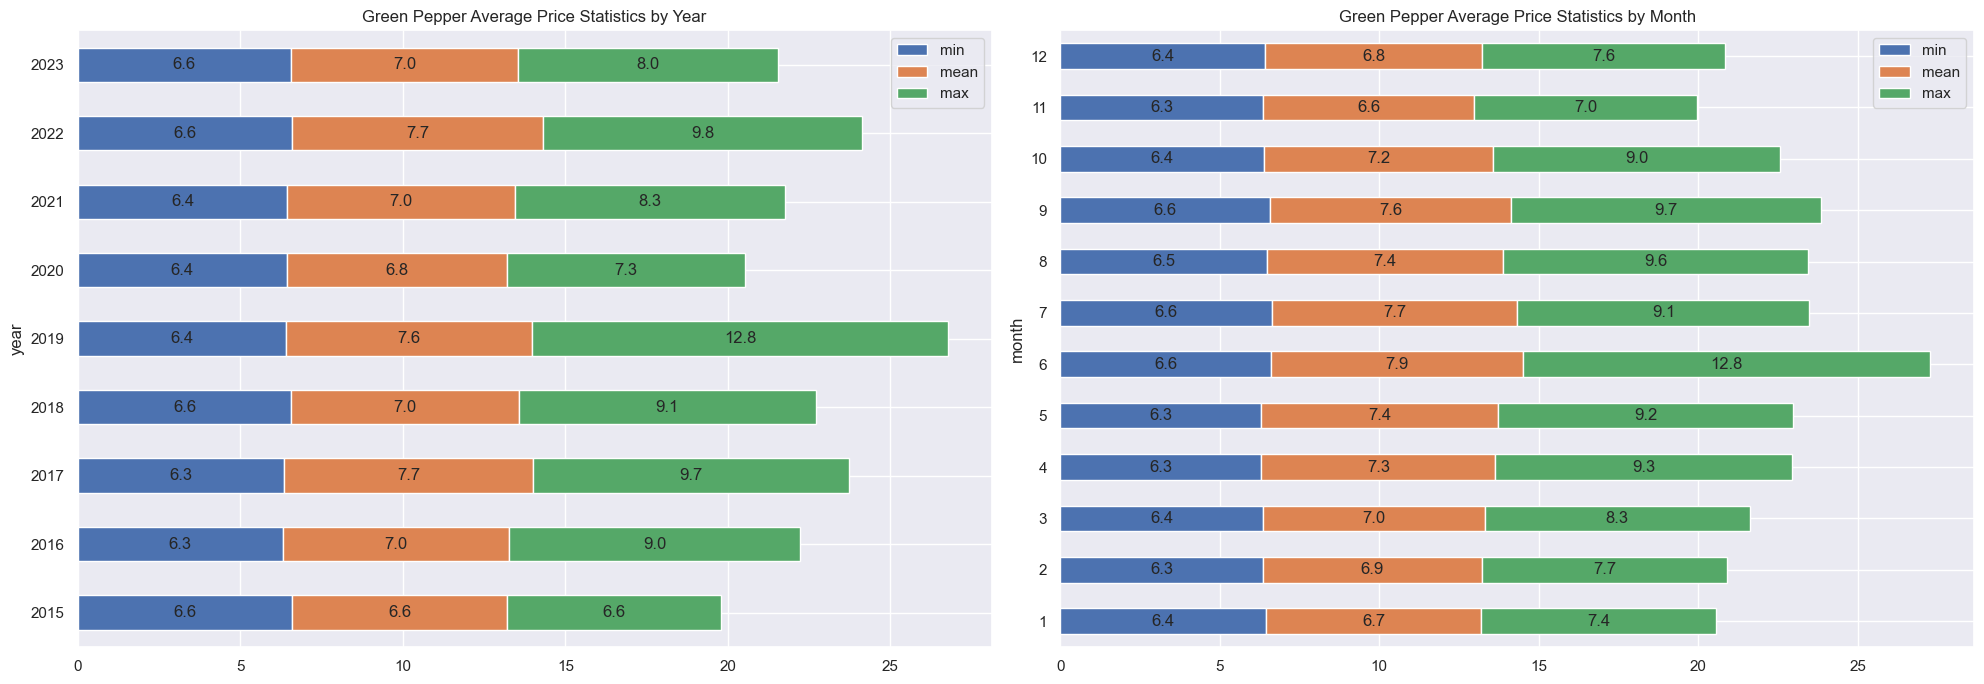

In [277]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

pd.DataFrame(df_ts_green.groupby("year")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    title='Green Pepper Average Price Statistics by Year'
)

pd.DataFrame(df_ts_green.groupby("month")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax2,
    title='Green Pepper Average Price Statistics by Month'
)


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')

plt.tight_layout()
plt.show()


*Green Bell Pepper Features developments:*

In [278]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Simple Moving Average</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Cummulative Moving Average</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Average</h4>
        {df3}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Weighted Average</h4>
        {df4}
    </div>

</div>
""".format(
    df1=M_resample_df_green.rolling(window=3).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df2=M_resample_df_green.expanding().mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df3=M_resample_df_green.ewm(alpha=.01,adjust=False).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df4=M_resample_df_green.ewm(span=12).mean().reset_index().head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))

Date,price
2015-12-31,NaN
2016-01-31,NaN
2016-02-29,6.517564
2016-03-31,6.434698
2016-04-30,6.343168
2016-05-31,6.423247
2016-06-30,6.738611
2016-07-31,7.019228
2016-08-31,7.033993
2016-09-30,7.443430


*Red Bell Pepper Features developments Visualization:*

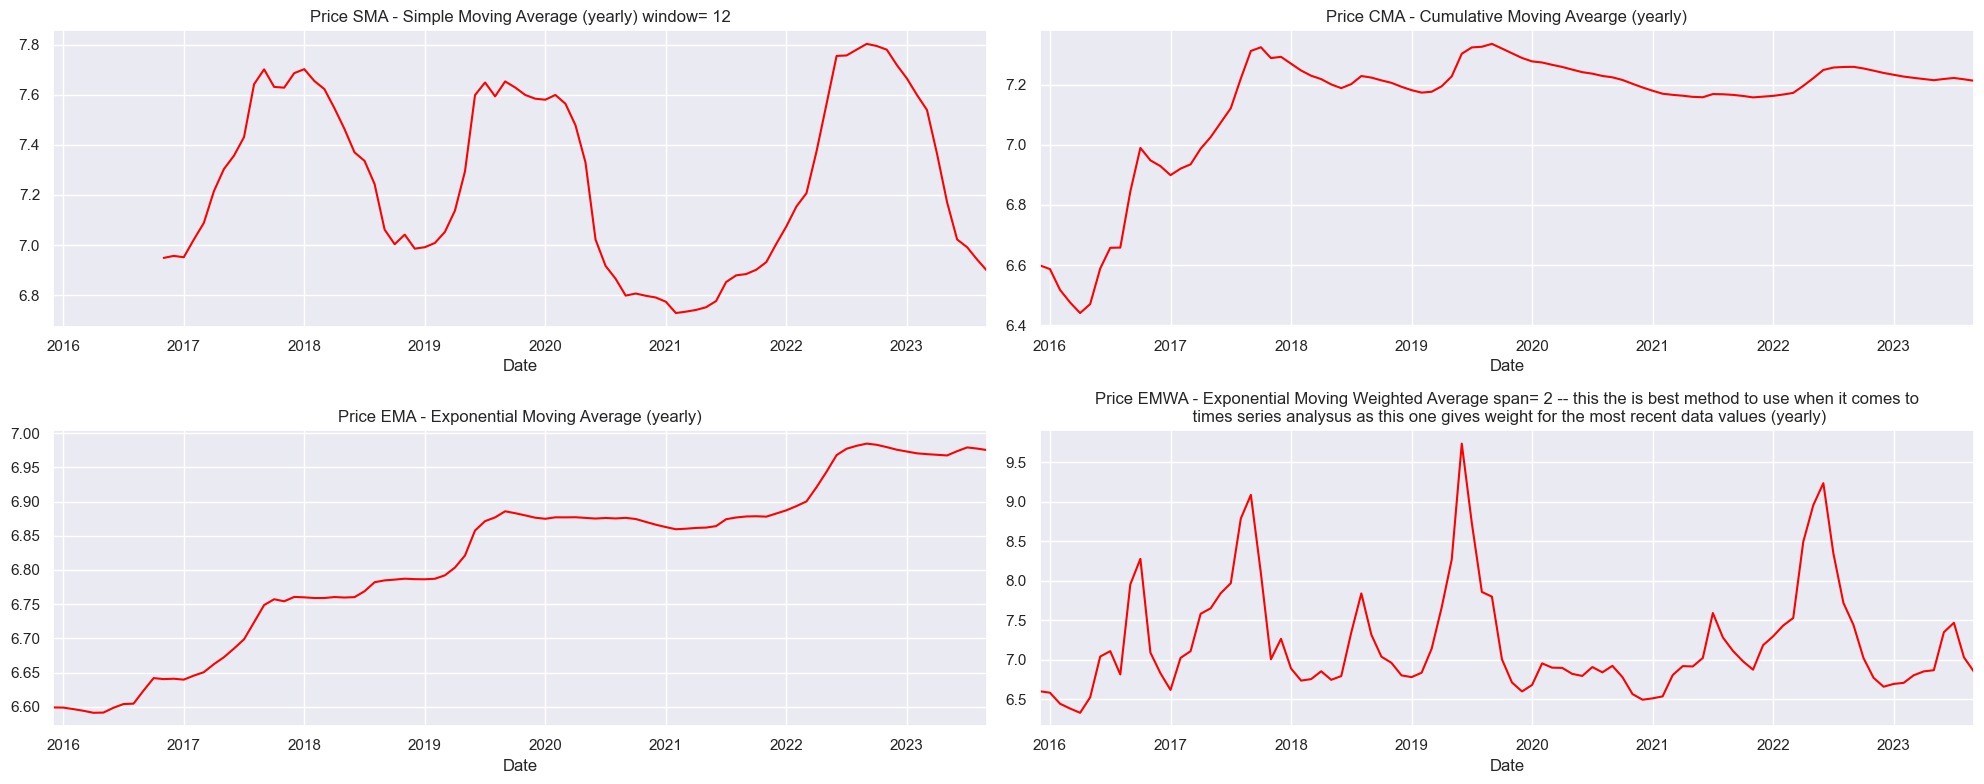

In [279]:
feature_development(Dataset=M_resample_df_green,Numericaltarget="price",rolling_window=12,span_n=2)

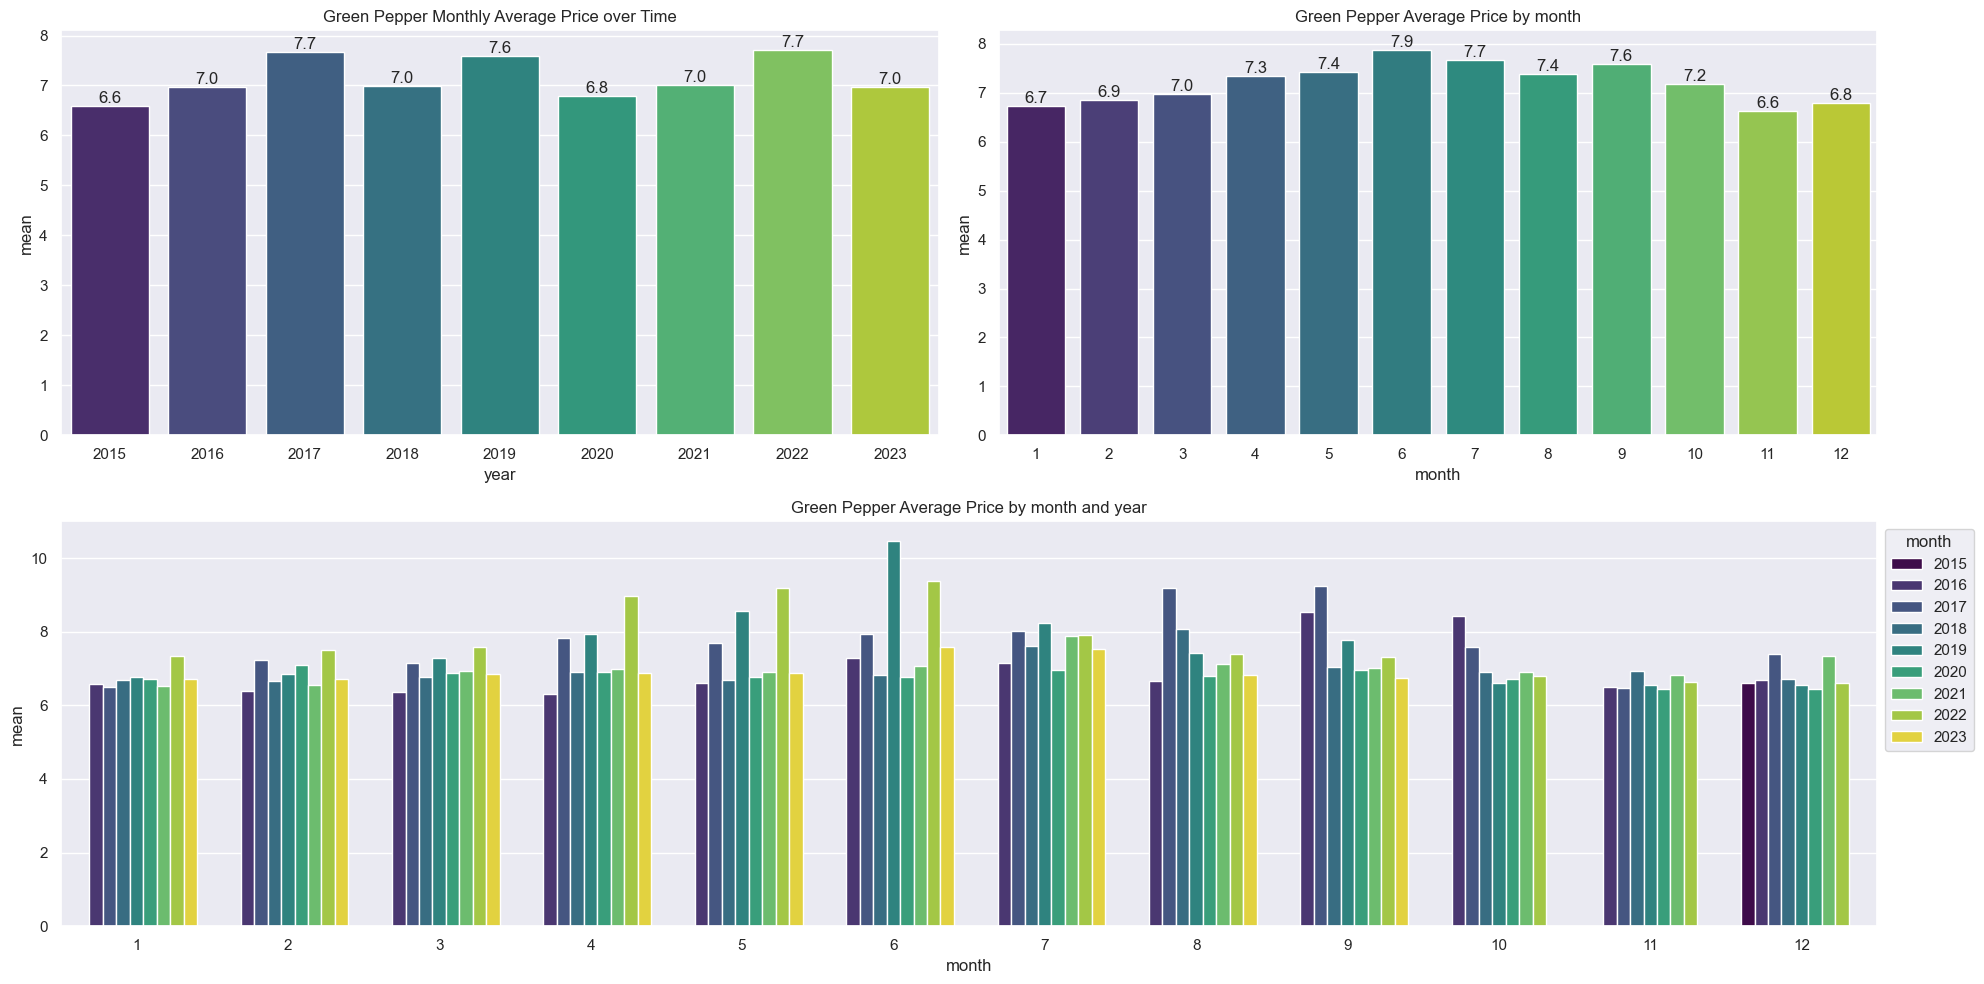

In [280]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1=sns.barplot(data=pd.DataFrame(df_ts_green.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index(),
            x="year", y="mean", palette="viridis",errorbar=None)
ax1.set_title("Green Pepper Monthly Average Price over Time")
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type="edge")

ax2 = fig.add_subplot(gs[0, 1])
ax2=sns.barplot(data=pd.DataFrame(df_ts_green.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", palette="viridis",errorbar=None)
ax2.set_title("Green Pepper Average Price by month")
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type="edge")

ax3 = fig.add_subplot(gs[1, :])
ax3=sns.barplot(data=pd.DataFrame(df_ts_green.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", hue="year",palette="viridis",legend=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
ax3.set_title("Green Pepper Average Price by month and year")
ax3.legend(title='month', bbox_to_anchor=(1, 1), loc='upper left');


plt.tight_layout()
plt.show()

* *Yellow Pepper Price*

*'min','mean','max' price of Yellow Bell Pepper color by year and month :*

In [283]:
from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Yellow Bell Pepper Basic Yearly Price Stats</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Yellow Bell Pepper Basic Monthly Price Stats</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Yellow Bell Pepper Top 10 Price by Year & Month</h4>
        {df3}
    </div>

</div>
""".format(
    df1=pd.DataFrame(df_ts_yellow.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df2=pd.DataFrame(df_ts_yellow.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index().to_html(classes='dataframe', index=False),
    df3=pd.DataFrame(df_ts_yellow.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))

year,min,mean,max
2015,7.300575,7.300575,7.300575
2016,7.031635,8.637669,10.474745
2017,7.715465,9.813603,13.600505
2018,7.074920,8.293208,10.650240
2019,7.102040,9.025108,14.084590
2020,7.049910,8.219889,10.250070
2021,7.299640,9.001985,11.600420
2022,7.300195,9.659391,13.300160
2023,7.250475,8.792197,12.579919
month,min,mean,max


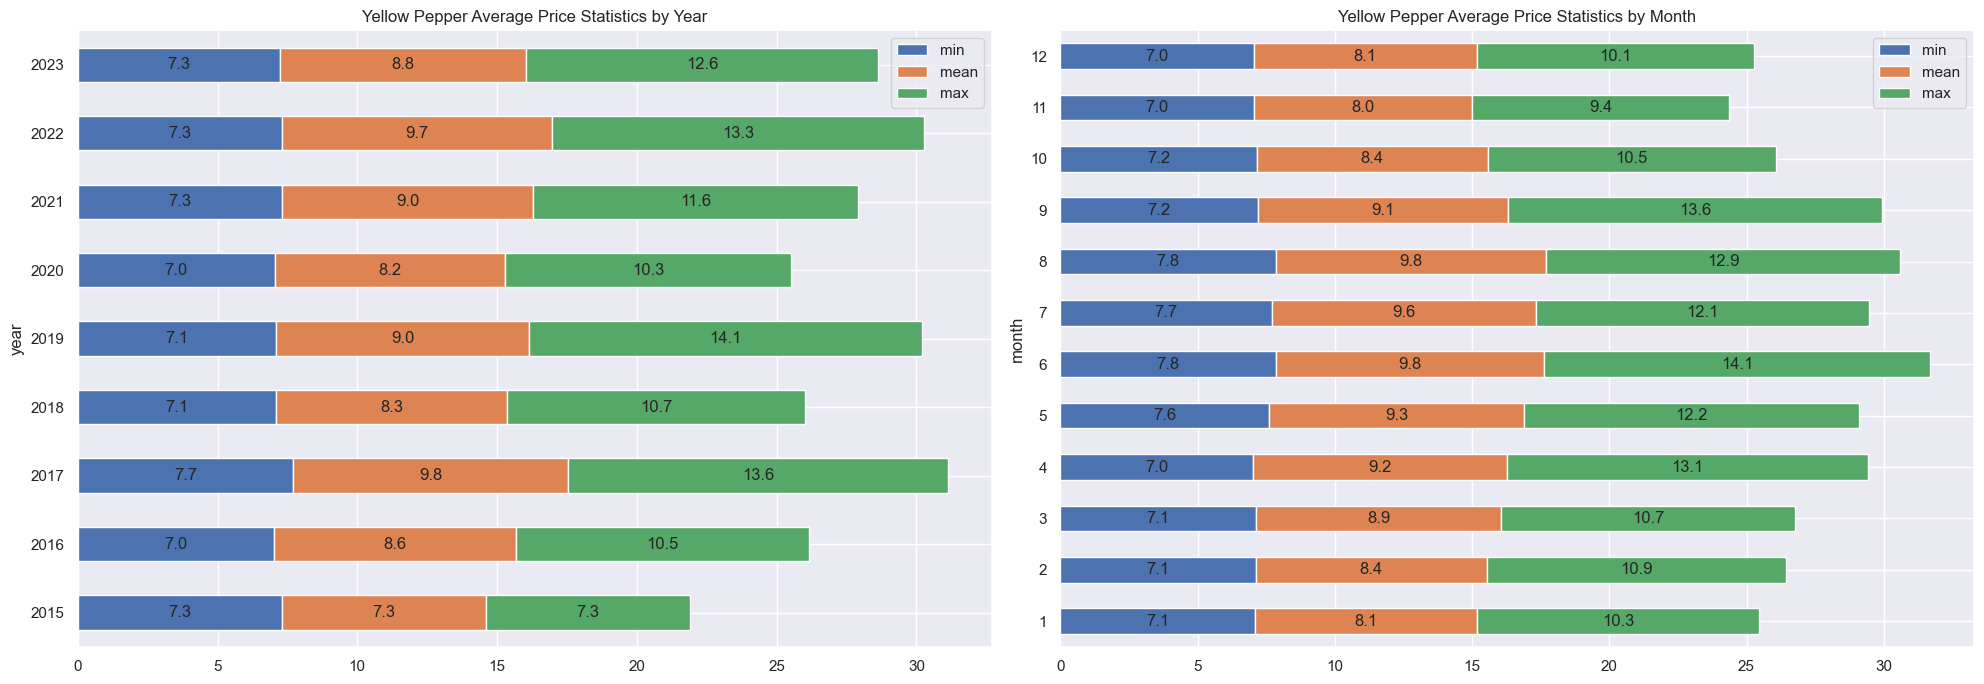

In [284]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

pd.DataFrame(df_ts_yellow.groupby("year")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    title='Yellow Pepper Average Price Statistics by Year'
)

pd.DataFrame(df_ts_yellow.groupby("month")["price"].agg(['min', 'mean', 'max'])).plot(
    kind="barh",
    stacked=True,
    ax=ax2,
    title='Yellow Pepper Average Price Statistics by Month'
)


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')

plt.tight_layout()
plt.show()

*Yellow Bell Pepper Features developments:*

In [285]:

from IPython.display import display, HTML

html = """
<div style="display: flex; gap: 50px; overflow-x: auto;">

    <div style="text-align: center;">
        <h4>Simple Moving Average</h4>
        {df1}
    </div>

    <div style="text-align: center;">
        <h4>Cummulative Moving Average</h4>
        {df2}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Average</h4>
        {df3}
    </div>

    <div style="text-align: center;">
        <h4>Exponential Moving Weighted Average</h4>
        {df4}
    </div>

</div>
""".format(
    df1=M_resample_df_yellow.rolling(window=3).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df2=M_resample_df_yellow.expanding().mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df3=M_resample_df_yellow.ewm(alpha=.01,adjust=False).mean().reset_index().head(10).to_html(classes='dataframe', index=False),
    df4=M_resample_df_yellow.ewm(span=12).mean().reset_index().head(10).to_html(classes='dataframe', index=False)
)

display(HTML(html))

Date,price
2015-12-31,NaN
2016-01-31,NaN
2016-02-29,7.243228
2016-03-31,7.193602
2016-04-30,7.139550
2016-05-31,7.584544
2016-06-30,8.355392
2016-07-31,9.386141
2016-08-31,9.739755
2016-09-30,9.953796


*Yellow Bell Pepper Features developments Visualization:*

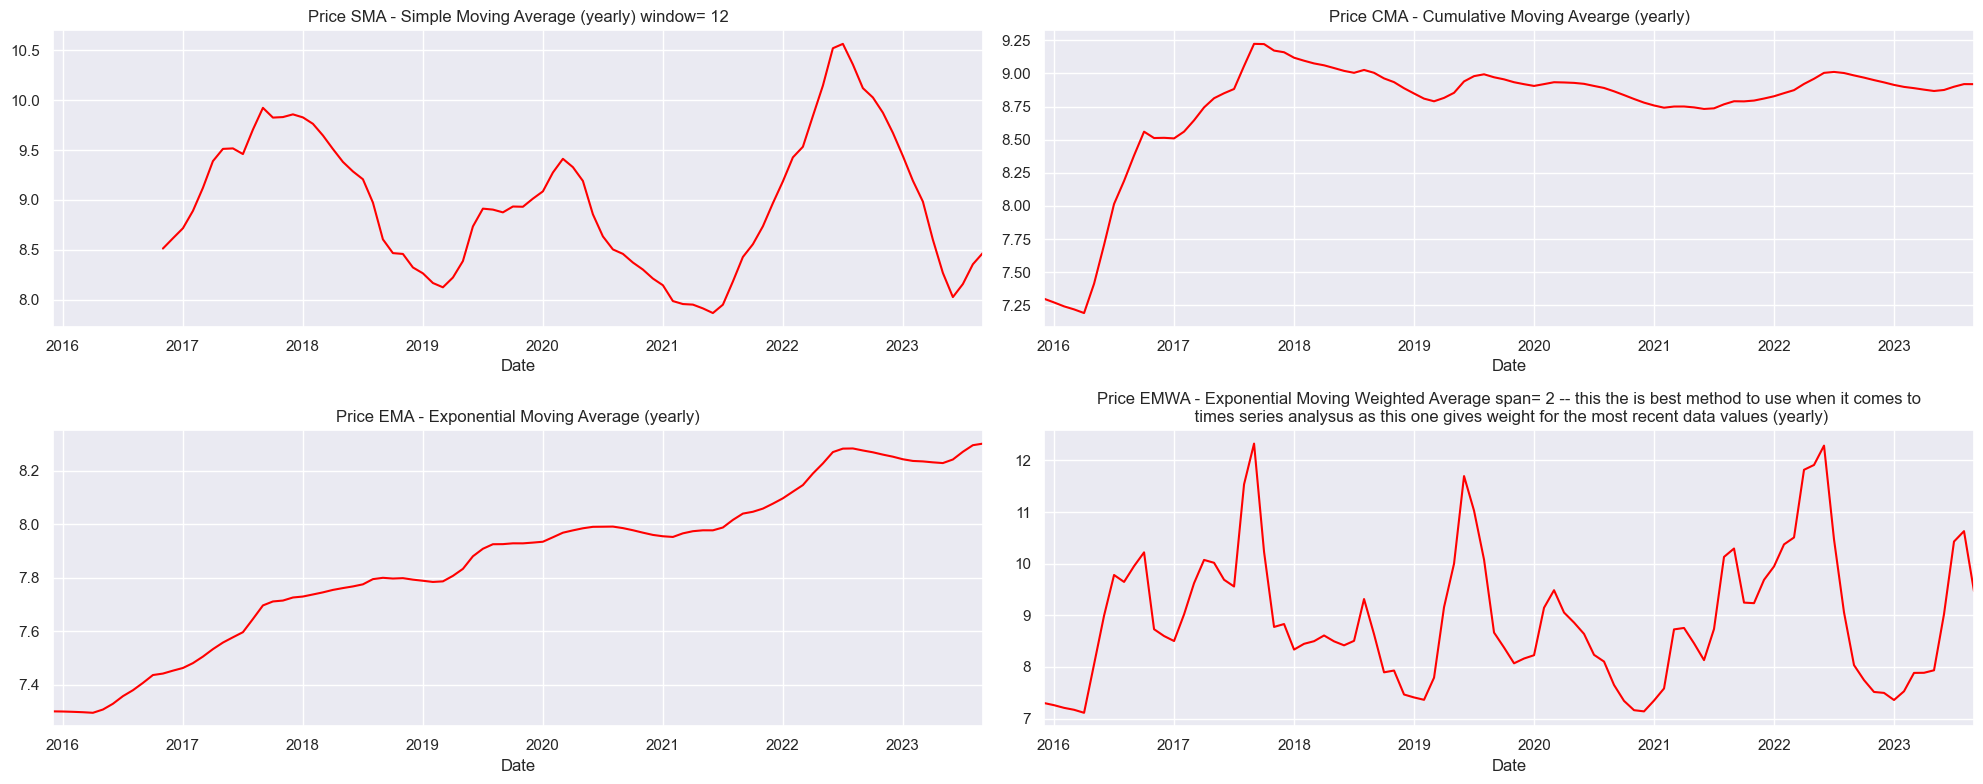

In [286]:
feature_development(Dataset=M_resample_df_yellow,Numericaltarget="price",rolling_window=12,span_n=2)

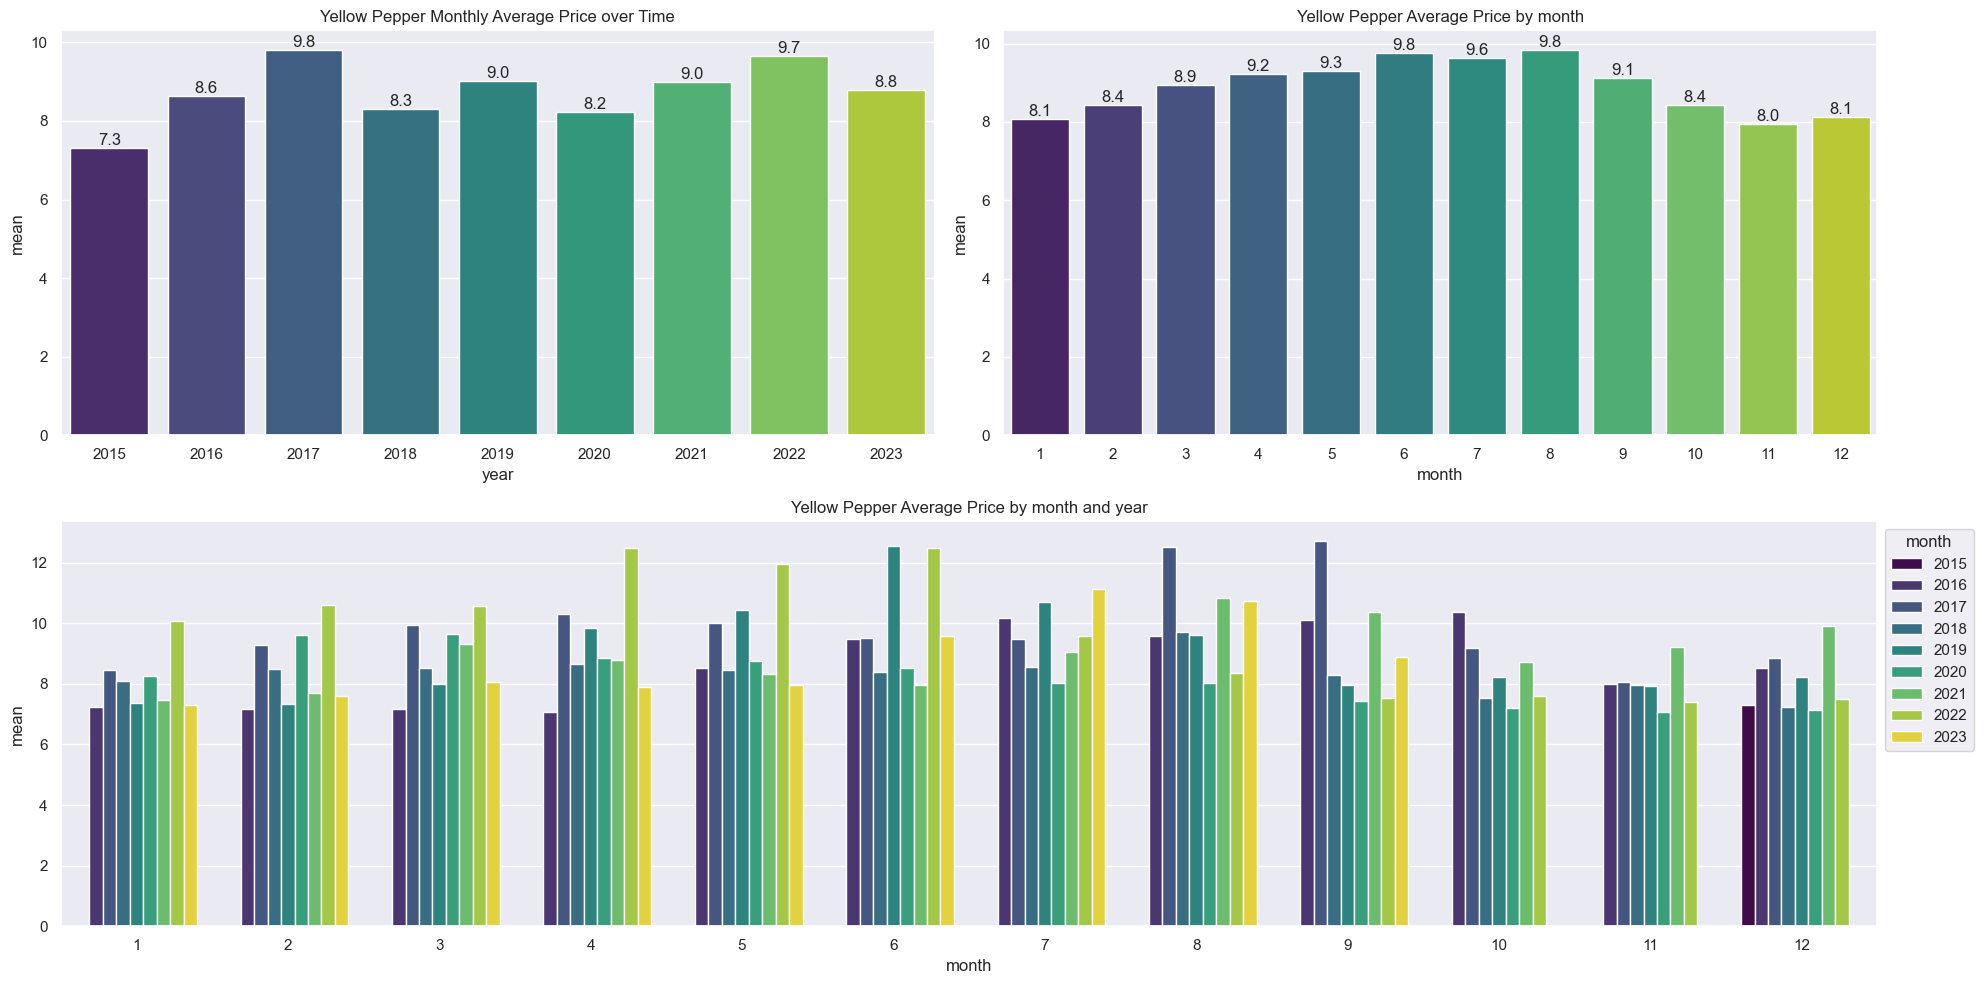

In [287]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1=sns.barplot(data=pd.DataFrame(df_ts_yellow.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index(),
            x="year", y="mean", palette="viridis",errorbar=None)
ax1.set_title("Yellow Pepper Monthly Average Price over Time")
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type="edge")

ax2 = fig.add_subplot(gs[0, 1])
ax2=sns.barplot(data=pd.DataFrame(df_ts_yellow.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", palette="viridis",errorbar=None)
ax2.set_title("Yellow Pepper Average Price by month")
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type="edge")

ax3 = fig.add_subplot(gs[1, :])
ax3=sns.barplot(data=pd.DataFrame(df_ts_yellow.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index(),
            x="month", y="mean", hue="year",palette="viridis",legend=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
ax3.set_title("Yellow Pepper Average Price by month and year")
ax3.legend(title='month', bbox_to_anchor=(1, 1), loc='upper left');


plt.tight_layout()
plt.show()